In [ ]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 624 (delta 168), reused 142 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (624/624), 30.17 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (426/426), done.
/content/ELENA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
import sys
import os
from pathlib import Path
import numpy as np
import time

# Get the directory of the current script
script_dir = Path(os.getcwd()).resolve()

# Add the src directory to the Python path
sys.path.append(str(Path(script_dir / '../src').resolve()))

figure_dir = '../data/processed/plots/manual/'
if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)

In [ ]:
def g_roll(lambda_):
    return ( ((16 * np.pi**2 * lambda_)/3) * (1 - lambda_ * (5 + 2*np.log(2) )/(8 * np.pi**2) ) )**(1/4)

In [ ]:
# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [ ]:
%%writefile custom_model.py
"""
custom_model.py

Paper-consistent Abelian-Higgs finite-temperature model
using a CosmoTransitions-compatible framework.

This version is designed to match the literature setup much more closely:

  V_eff(phi, T; mu) =
      V_tree(phi; mu)
    + V_CW(phi; mu)
    + V_T(phi, T; mu)
    + V_Daisy(phi, T; mu)

with

  V_tree(phi) = - m^2(mu) phi^2 / 2 + lambda(mu) phi^4 / 4

field-dependent masses:
  m_h^2(phi) = 3 lambda(phi) phi^2 - m^2
  m_g^2(phi) = lambda(phi) phi^2 - m^2
  m_A^2(phi) = g^2 phi^2

thermal masses from the paper:
  Pi_{h,g} = lambda T^2 / 3 + g^2 T^2 / 4
  Pi_{A_L} = g^2 T^2 / 3

RGEs from the paper:
  beta_{g^2} = g^4 / (24 pi^2)
  beta_lambda = (10 lambda^2 - 6 lambda g^2 + 3 g^4) / (8 pi^2)
  beta_{m^2} = m^2 (4 lambda - 3 g^2) / (8 pi^2)

Default scale choice:
  mu(T) = pi T    for T > 0
  mu(0) = mu0     fallback

Notes
-----
1. This file keeps the GenericCTModel wrapper so your existing workflow
   remains familiar.
2. The CW piece is implemented directly in MS-bar/Landau-gauge style.
3. Daisy resummation uses the Arnold-Espinosa prescription.
4. For numerical stability, logarithms use abs(m^2) inside logs and small
   regulators near zero. This is a practical real-valued implementation.
"""

import numpy as np
from scipy.integrate import solve_ivp

from cosmoTransitions import generic_potential, helper_functions


# -------------------------
# Small stability utilities
# -------------------------
def _as_float_array(x):
    return np.asanyarray(x, dtype=float)

def _as_float_scalar(x):
    return float(np.asanyarray(x, dtype=float))

def _clip_m2_nonneg(m2):
    return np.maximum(np.asanyarray(m2, dtype=float), 0.0)

def _finite_or_big(y, big=1e300):
    """
    Replace non-finite values by a huge barrier value.
    Works on scalars and arrays.
    """
    y = np.asanyarray(y)
    if np.isscalar(y) or y.shape == ():
        return y if np.isfinite(y) else big
    out = y.copy()
    mask = ~np.isfinite(out)
    if np.any(mask):
        out[mask] = big
    return out

def _adaptive_T_step(T, eps_abs=1e-6, eps_rel=1e-3, Tmin_step=1e-6):
    T = float(T)
    return max(float(eps_abs), float(eps_rel) * abs(T), float(Tmin_step))

def _safe_log_argument(x, floor=1e-300):
    """
    Stable positive argument for logarithms.
    """
    x = np.asanyarray(x, dtype=float)
    return np.maximum(np.abs(x), floor)

def _safe_mass4_log_term(m2, mu2, const):
    """
    Stable real-valued implementation of m^4 [ln(m^2/mu^2) - const].
    Uses |m^2| inside the log, which is a common practical real-valued choice
    in effective-potential numerics.
    """
    m2 = np.asanyarray(m2, dtype=float)
    mu2 = float(mu2)
    return (m2 ** 2) * (np.log(_safe_log_argument(m2) / mu2) - const)


# --------------------------------
# Generic CT-style engine
# --------------------------------
class GenericCTModel(generic_potential.generic_potential):
    """
    Generic CosmoTransitions-compatible model.

    You supply:
      - V0_fun(X, T)               : tree-level piece
      - boson_fun(X, T)            : (M2, dof, c)
      - fermion_fun(X)             : (M2, dof)
      - Vct_fun(X, T)              : optional counterterm-like piece
      - Vcw_fun(X, T)              : optional custom zero-T loop piece
      - use_ct_cw                  : whether to use CT's built-in V1 or Vcw_fun
      - daisyType:
          0 -> no daisy
          1 -> Parwani
          2 -> Arnold-Espinosa
    """

    def init(
        self,
        Ndim,
        V0_fun,
        boson_fun,
        fermion_fun=None,
        Vct_fun=None,
        Vcw_fun=None,
        use_ct_cw=False,
        xstep=1e-3,
        Tstep_abs=1e-4,
        Tstep_rel=1e-3,
        Tmin_step=1e-6,
        daisyType=2,
        deriv_order=2,
    ):
        self.Ndim = int(Ndim)
        if V0_fun is None or boson_fun is None:
            raise ValueError("GenericCTModel requires at least V0_fun and boson_fun.")

        self._V0_fun = V0_fun
        self._boson_fun = boson_fun
        self._fermion_fun = fermion_fun if fermion_fun is not None else (lambda X: (0.0, 0.0))
        self._Vct_fun = Vct_fun if Vct_fun is not None else (lambda X, T: 0.0)
        self._Vcw_fun = Vcw_fun if Vcw_fun is not None else (lambda X, T: 0.0)

        self.use_ct_cw = bool(use_ct_cw)

        self.x_eps = float(xstep)
        self.T_eps_abs = float(Tstep_abs)
        self.T_eps_rel = float(Tstep_rel)
        self.Tmin_step = float(Tmin_step)

        self.daisyResum = int(daisyType)
        self.deriv_order = int(deriv_order)

    # CT-required
    def V0(self, X):
        # Fallback required by CT interface, but our actual Vtot below calls V0_fun(X, T)
        return self._V0_fun(_as_float_array(X), 0.0)

    def Vct(self, X):
        return self._Vct_fun(_as_float_array(X), 0.0)

    def boson_massSq(self, X, T):
        return self._boson_fun(_as_float_array(X), _as_float_scalar(T))

    def fermion_massSq(self, X):
        return self._fermion_fun(_as_float_array(X))

    def Vtot(self, X, T, include_radiation=True):
        X = _as_float_array(X)
        T = _as_float_array(T)

        fermions = self.fermion_massSq(X)
        bosons0 = self.boson_massSq(X, 0.0 * T)

        y = self._V0_fun(X, T)

        # Zero-temperature loop piece
        if self.use_ct_cw:
            y = y + self.V1(bosons0, fermions) + self._Vct_fun(X, T)
        else:
            y = y + self._Vcw_fun(X, T) + self._Vct_fun(X, T)

        # Thermal + daisy
        if self.daisyResum == 0:
            y = y + self.V1T(bosons0, fermions, T, include_radiation)

        elif self.daisyResum == 1:
            bosonsT = self.boson_massSq(X, T)
            y = y + self.V1T(bosonsT, fermions, T, include_radiation)

        elif self.daisyResum == 2:
            # Arnold-Espinosa: V1T(bosons0) + ring from bosonsT - bosons0
            bosonsT = self.boson_massSq(X, T)
            m20, nb, _ = bosons0
            m2T, _, _ = bosonsT

            m20c = _clip_m2_nonneg(m20)
            m2Tc = _clip_m2_nonneg(m2T)

            Vring = -(T / (12.0 * np.pi)) * np.sum(
                nb * (np.power(m2Tc, 1.5) - np.power(m20c, 1.5)),
                axis=-1
            )
            y = y + self.V1T(bosons0, fermions, T, include_radiation) + Vring

        else:
            raise ValueError("daisyType must be 0, 1, or 2.")

        return _finite_or_big(y)

    def DVtot(self, X, T):
        X = _as_float_array(X)
        return self.Vtot(X, T, include_radiation=False) - self.Vtot(X * 0.0, T, include_radiation=False)

    def gradV(self, X, T):
        try:
            f = self._gradV
        except AttributeError:
            self._gradV = helper_functions.gradientFunction(
                self.Vtot, self.x_eps, self.Ndim, self.deriv_order
            )
            f = self._gradV

        T = np.asanyarray(T)[..., np.newaxis, np.newaxis]
        return f(X, T, False)

    # -------------------------------
    # Temperature derivatives (stable)
    # -------------------------------
    def dVdT(self, X, T, include_radiation=True, include_SM=False, units="GeV"):
        X = _as_float_array(X)
        T = float(T)

        h = _adaptive_T_step(
            T,
            eps_abs=self.T_eps_abs,
            eps_rel=self.T_eps_rel,
            Tmin_step=self.Tmin_step,
        )

        if T <= h:
            V0 = self.Vtot(X, 0.0, include_radiation=include_radiation)
            V1 = self.Vtot(X, h, include_radiation=include_radiation)
            d = (V1 - V0) / h
        else:
            Vm = self.Vtot(X, T - h, include_radiation=include_radiation)
            Vp = self.Vtot(X, T + h, include_radiation=include_radiation)
            d = (Vp - Vm) / (2.0 * h)

        # No SM subtraction in this minimal paper model
        return d

    def d2VdT2(self, X, T, include_radiation=True, include_SM=False, units="GeV"):
        X = _as_float_array(X)
        T = float(T)

        h = _adaptive_T_step(
            T,
            eps_abs=self.T_eps_abs,
            eps_rel=self.T_eps_rel,
            Tmin_step=self.Tmin_step,
        )

        if T <= 2.0 * h:
            V0 = self.Vtot(X, 0.0, include_radiation=include_radiation)
            Vh = self.Vtot(X, h, include_radiation=include_radiation)
            V2h = self.Vtot(X, 2.0 * h, include_radiation=include_radiation)
            val = (V2h - 2.0 * Vh + V0) / (h * h)
        else:
            Vm = self.Vtot(X, T - h, include_radiation=include_radiation)
            Vc = self.Vtot(X, T, include_radiation=include_radiation)
            Vp = self.Vtot(X, T + h, include_radiation=include_radiation)
            val = (Vp - 2.0 * Vc + Vm) / (h * h)

        return val


# ---------------------------------------------------------
# Paper-consistent Abelian-Higgs 4D HT + Daisy model
# ---------------------------------------------------------
class AbelianHiggsMSbarPaper(GenericCTModel):
    """
    Abelian-Higgs model matched to the paper's 4D scheme.

    Parameters are defined at a reference scale mu0:
      g2(mu0), lambda(mu0), m2(mu0)

    Tree-level potential:
      V_tree = -m2(mu) phi^2 / 2 + lambda(mu) phi^4 / 4

    Field-dependent masses:
      m_h^2 = 3 lambda(mu) phi^2 - m2(mu)
      m_g^2 =   lambda(mu) phi^2 - m2(mu)
      m_A^2 = g2(mu) phi^2

    Thermal masses:
      Pi_{h,g} = lambda(mu) T^2 / 3 + g2(mu) T^2 / 4
      Pi_{A_L} = g2(mu) T^2 / 3

    Default renormalization scale:
      mu(T) = pi T  for T > 0
      mu(0) = mu0
    """

    def init(
        self,
        g2_0=0.36,          # g(mu0)^2
        lambda_0=0.0,       # lambda(mu0)
        m2_0=0.0,           # m^2(mu0), note paper tree uses -m^2 phi^2 / 2
        mu0=1.0,            # reference scale
        use_running=True,
        use_paper_mu=True,  # mu(T) = pi T for T>0, else mu0
        xstep=5e-5,
        Tstep_abs=1e-4,
        Tstep_rel=1e-3,
        Tmin_step=1e-6,
        deriv_order=2,
        daisyType=2,        # Arnold-Espinosa by default
    ):
        self.g2_0 = float(g2_0)
        self.lambda_0 = float(lambda_0)
        self.m2_0 = float(m2_0)
        self.mu0 = float(mu0)

        self.use_running = bool(use_running)
        self.use_paper_mu = bool(use_paper_mu)

        # cache for repeated running evaluations
        self._rge_cache = {}

        # -------------------------
        # scale choice
        # -------------------------
        def mu_eff(T):
            T = float(np.asanyarray(T, dtype=float))
            if self.use_paper_mu and T > 0.0:
                return max(np.pi * T, 1e-12)
            return max(self.mu0, 1e-12)

        self.mu_eff = mu_eff

        # -------------------------
        # one-loop RGEs from paper
        # -------------------------
        def rge_rhs(t, y):
            # t = ln(mu / mu0)
            g2, lam, m2 = y

            beta_g2 = (g2 ** 2) / (24.0 * np.pi ** 2)
            beta_lam = (10.0 * lam ** 2 - 6.0 * lam * g2 + 3.0 * g2 ** 2) / (8.0 * np.pi ** 2)
            beta_m2 = m2 * (4.0 * lam - 3.0 * g2) / (8.0 * np.pi ** 2)

            return [beta_g2, beta_lam, beta_m2]

        self._rge_rhs = rge_rhs

        def run_params(mu):
            """
            Return g2(mu), lambda(mu), m2(mu).
            """
            mu = max(float(mu), 1e-12)

            if not self.use_running:
                return self.g2_0, self.lambda_0, self.m2_0

            key = round(mu, 12)
            if key in self._rge_cache:
                return self._rge_cache[key]

            if abs(mu - self.mu0) / max(self.mu0, 1e-12) < 1e-14:
                out = (self.g2_0, self.lambda_0, self.m2_0)
                self._rge_cache[key] = out
                return out

            t1 = np.log(mu / self.mu0)
            sol = solve_ivp(
                self._rge_rhs,
                (0.0, t1),
                [self.g2_0, self.lambda_0, self.m2_0],
                method="RK45",
                rtol=1e-8,
                atol=1e-10,
                dense_output=False,
                max_step=max(abs(t1) / 100.0, 1e-3),
            )
            if not sol.success:
                raise RuntimeError(f"RGE evolution failed: {sol.message}")

            g2_mu, lam_mu, m2_mu = [float(v) for v in sol.y[:, -1]]
            out = (g2_mu, lam_mu, m2_mu)
            self._rge_cache[key] = out
            return out

        self.run_params = run_params

        # -------------------------
        # masses at given (phi, T)
        # -------------------------
        def masses_zeroT(phi, T):
            mu = self.mu_eff(T)
            g2, lam, m2 = self.run_params(mu)

            mH2 = 3.0 * lam * phi ** 2 - m2
            mG2 = 1.0 * lam * phi ** 2 - m2
            mA2 = g2 * phi ** 2
            return mH2, mG2, mA2, g2, lam, m2, mu

        self.masses_zeroT = masses_zeroT

        # -------------------------
        # tree-level piece
        # -------------------------
        def V0_fun(X, T):
            X = _as_float_array(X)
            phi = X[..., 0]

            _, _, _, _, lam, m2, _ = self.masses_zeroT(phi, T)
            return -0.5 * m2 * phi ** 2 + 0.25 * lam * phi ** 4

        # -------------------------
        # MS-bar Coleman-Weinberg
        # -------------------------
        def Vcw_msbar(X, T):
            X = _as_float_array(X)
            phi = X[..., 0]

            mH2, mG2, mA2, _, _, _, mu = self.masses_zeroT(phi, T)
            mu2 = mu ** 2

            # Paper-like Landau-gauge CW:
            #   m_h^4 [ln(m_h^2/mu^2) - 3/2]
            # + m_g^4 [ln(m_g^2/mu^2) - 3/2]
            # + 3 m_A^4 [ln(m_A^2/mu^2) - 5/6]
            termH = _safe_mass4_log_term(mH2, mu2, 1.5)
            termG = _safe_mass4_log_term(mG2, mu2, 1.5)
            termA = 3.0 * _safe_mass4_log_term(mA2, mu2, 5.0 / 6.0)

            return (termH + termG + termA) / (64.0 * np.pi ** 2)

        # -------------------------
        # bosonic spectrum
        # -------------------------
        def boson_fun(X, T):
            """
            Returns [H, G, A_T, A_L] with dof [1,1,2,1].

            For T > 0:
              Pi_{H,G} = lambda T^2 / 3 + g^2 T^2 / 4
              Pi_{A_L} = g^2 T^2 / 3
              A_T is not Debye-resummed
            """
            X = _as_float_array(X)
            phi = X[..., 0]
            T = float(np.asanyarray(T, dtype=float))

            mH2, mG2, mA2, g2, lam, _, _ = self.masses_zeroT(phi, T)

            if T > 0.0:
                PiS = (lam / 3.0 + g2 / 4.0) * T ** 2
                PiL = (g2 / 3.0) * T ** 2

                mH2_eff = mH2 + PiS
                mG2_eff = mG2 + PiS
                mAT2_eff = mA2
                mAL2_eff = mA2 + PiL
            else:
                mH2_eff = mH2
                mG2_eff = mG2
                mAT2_eff = mA2
                mAL2_eff = mA2

            M2 = np.stack([mH2_eff, mG2_eff, mAT2_eff, mAL2_eff], axis=-1)
            dof = np.array([1.0, 1.0, 2.0, 1.0])
            c = np.array([1.5, 1.5, 5.0 / 6.0, 5.0 / 6.0])
            return M2, dof, c

        def fermion_fun(X):
            return 0.0, 0.0

        super().init(
            Ndim=1,
            V0_fun=V0_fun,
            boson_fun=boson_fun,
            fermion_fun=fermion_fun,
            Vct_fun=None,
            Vcw_fun=Vcw_msbar,
            use_ct_cw=False,
            xstep=xstep,
            Tstep_abs=Tstep_abs,
            Tstep_rel=Tstep_rel,
            Tmin_step=Tmin_step,
            daisyType=daisyType,
            deriv_order=deriv_order,
        )

    def approxZeroTMin(self):
        """
        Approximate zero-temperature minimum from tree level:
          phi^2 = m^2 / lambda  when lambda > 0 and m^2 > 0.
        """
        g2, lam, m2 = self.run_params(self.mu0)

        if lam > 0.0 and m2 > 0.0:
            vev = np.sqrt(m2 / lam)
            return [np.array([vev], dtype=float)]

        return [np.array([0.0], dtype=float)]


# Compatibility alias
DarkPhotonMSbarRG = AbelianHiggsMSbarPaper

Writing custom_model.py


In [ ]:
import numpy as np
import sys, importlib

# Reload the new paper-consistent module if already imported
if 'custom_model' in sys.modules:
    importlib.reload(sys.modules['custom_model'])

from custom_model import AbelianHiggsMSbarPaper

# Paper-style 4D benchmark used for the GW spectrum comparison
# Fig. 6 uses g(mu0)=0.6, with mu0=1 GeV, lambda(mu0)=0, m^2(mu0)=0
description = "4D benchmark (g=0.6)"
g0 = 0.60
g2_0 = g0**2
lambda_0 = 0.0
m2_0 = 0.0
mu0 = 1.0  # GeV

# Build the 4D model in the paper's scheme
dp = AbelianHiggsMSbarPaper(
    g2_0=g2_0,
    lambda_0=lambda_0,
    m2_0=m2_0,
    mu0=mu0,
    use_running=True,     # RG running
    use_paper_mu=True,    # mu(T) = pi*T for T > 0
    xstep=5e-5,
    Tstep_abs=5e-5,
    Tstep_rel=1e-3,
    Tmin_step=1e-6,
    deriv_order=2,
    daisyType=2,          # Arnold-Espinosa daisy
)

phi_test = 10.0
T_test = 0.2  # GeV

# Same wrapper style as before
V  = lambda phi, T: dp.DVtot(np.atleast_1d(phi).reshape(-1, 1), T)
dV = lambda phi, T: dp.gradV(np.atleast_1d(phi).reshape(-1, 1), T)[..., 0]

# Running parameters at the paper scale choice mu = pi T
mu_test = dp.mu_eff(T_test)
g2_run, lam_run, m2_run = dp.run_params(mu_test)

print(description)
print("V(10,0.2) =", V(phi_test, T_test))
print("dV/dphi(10,0.2) =", dV(phi_test, T_test))
print("Zero-T minimum guess =", dp.approxZeroTMin())
print("Reference-scale inputs:")
print("  mu0 =", dp.mu0)
print("  g^2(mu0) =", dp.g2_0)
print("  lambda(mu0) =", dp.lambda_0)
print("  m^2(mu0) =", dp.m2_0)
print("At T_test, mu_eff =", mu_test)
print("Running parameters at mu_eff:")
print("  g^2(mu_eff) =", g2_run)
print("  lambda(mu_eff) =", lam_run)
print("  m^2(mu_eff) =", m2_run)

4D benchmark (g=0.6)
V(10,0.2) = [16.86216701]
dV/dphi(10,0.2) = [7.97384246]
Zero-T minimum guess = [array([0.])]
Reference-scale inputs:
  mu0 = 1.0
  g^2(mu0) = 0.36
  lambda(mu0) = 0.0
  m^2(mu0) = 0.0
At T_test, mu_eff = 0.6283185307179586
Running parameters at mu_eff:
  g^2(mu_eff) = 0.35974592170483227
  lambda(mu_eff) = -0.0023014022452005805
  m^2(mu_eff) = 0.0


In [ ]:
vev=w

In [ ]:
units="MeV"

In [ ]:
import numpy as np
from temperatures import find_T_min, find_T_max, refine_Tmin

# Units used in the paper-style setup above
units = "GeV"

# Choose a practical field/temperature scale for ELENA scans
# Since the conformal setup does not give you a fixed tree-level vev input,
# use a numerical scan scale instead of "vev".
scan_scale = 1.0   # GeV, start simple; enlarge later if needed

# ELENA expects V(phi,T) and dV(phi,T) with scalar/array phi input.
# Make wrappers that return plain numpy arrays.
def V(phi, T):
    phi_arr = np.atleast_1d(phi).astype(float).reshape(-1, 1)
    out = dp.DVtot(phi_arr, T)
    return np.asarray(out, dtype=float)

def dV(phi, T):
    phi_arr = np.atleast_1d(phi).astype(float).reshape(-1, 1)
    out = dp.gradV(phi_arr, T)[..., 0]
    return np.asarray(out, dtype=float)

T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
    V,
    dV,
    precision=1e-2,
    Phimax=2.0 * scan_scale,
    step_phi=1e-2 * scan_scale,
    tmax=2.5 * scan_scale,
)

T_min, vevs_min, false_min_tmin = find_T_min(
    V,
    dV,
    tmax=T_max,
    precision=1e-2,
    Phimax=2.0 * scan_scale,
    step_phi=1e-2 * scan_scale,
    max_min_vals=max_min_vals,
)

if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None

T_min = refine_Tmin(T_min, V, dV, maxvev, log_10_precision=6) if T_min is not None else None

if T_max is not None:
    print(f"T_max = {T_max:.6e} {units}")
else:
    print("T_max = None")

if T_min is not None:
    print(f"T_min = {T_min:.6e} {units}")
else:
    print("T_min = None")

print("maxvev =", maxvev)

T_max = 3.755000e-01 GeV
T_min = 2.002578e-03 GeV
maxvev = 2.331810048262061


In [ ]:
T_max, vevs_max, max_min_vals, false_min_tmax

(np.float64(0.37550000000000777),
 array([1.87738015, 1.87740195, 1.87668747]),
 [0.9504355785660099, 1.8766874718768753],
 [0, 0])

In [ ]:
T_min, vevs_min, false_min_tmin

(np.float64(0.002002578404185474), array([2.33181005]), [0, 0])

In [ ]:
maxvev

np.float64(2.331810048262061)

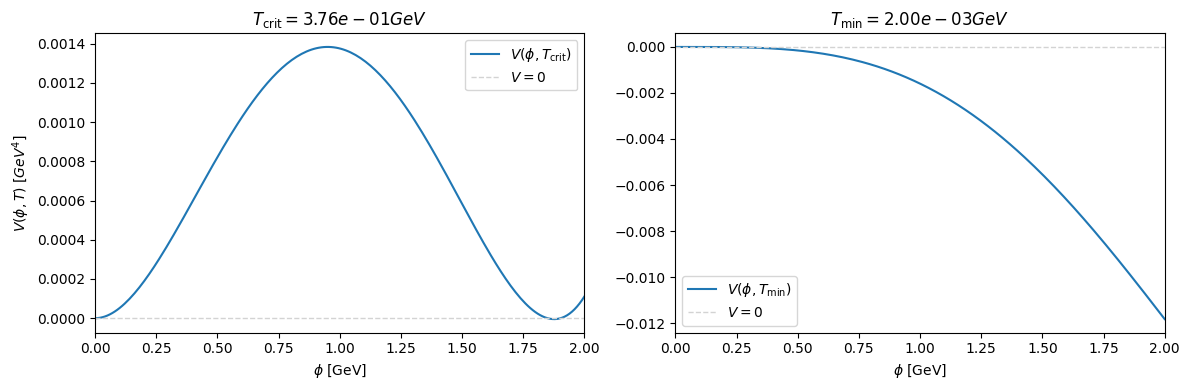

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False

# Define a plotting range (no vev anymore)
phi = np.linspace(0.0, 2.0, 200)  # adjust if needed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# Critical temperature plot
# -------------------------
if T_max is not None:
    v_max = V(phi, T_max)
    axes[0].plot(phi, v_max, label=r'$V(\phi, T_{\mathrm{crit}})$')
    axes[0].set_title(f'$T_{{\\mathrm{{crit}}}} = {T_max:.2e} {units}$')
    axes[0].set_xlim(phi[0], phi[-1])
    axes[0].set_ylabel(f"$V(\\phi, T)$ $[{units}^4]$")

# -------------------------
# Barrier disappearance plot
# -------------------------
if T_min is not None:
    v_min = V(phi, T_min)
    axes[1].plot(phi, v_min, label=r'$V(\phi, T_{\mathrm{min}})$')
    axes[1].set_title(f'$T_{{\\mathrm{{min}}}} = {T_min:.2e} {units}$')
    axes[1].set_xlim(phi[0], phi[-1])

# -------------------------
# Common formatting
# -------------------------
for ax in axes:
    ax.set_xlabel(f"$\\phi$ [{units}]")
    ax.axhline(0.0, color='lightgrey', linestyle='--', linewidth=1, label="$V=0$")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
from espinosa import Vt_vec
import numpy as np

true_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}
false_vev = {}

def action_over_T(T, c_step_phi=1e-3, precision=1e-3):
    T = float(T)

    # Fallback if maxvev was not determined cleanly
    vev0_guess = float(maxvev) if maxvev is not None and np.isfinite(maxvev) and maxvev > 0 else 1.0

    instance = Vt_vec(
        T,
        V,
        dV,
        step_phi=c_step_phi,
        precision=precision,
        vev0=vev0_guess,
        ratio_vev_step0=50,
    )

    if instance.barrier:
        true_vev[T] = float(instance.true_min)
        false_vev[T] = float(instance.phi_original_false_vev)
        S3overT[T] = float(instance.action_over_T)
        V_min_value[T] = float(instance.min_V)
        phi0_min[T] = float(instance.phi0_min)
        V_exit[T] = float(instance.V_exit)
        return float(instance.action_over_T)
    else:
        return None

In [ ]:
import time
import numpy as np

n_points = 100

if T_min is None or T_max is None:
    raise RuntimeError("T_min or T_max is None. Run the temperature finder first and make sure a barrier exists.")

temperatures_scan = np.linspace(float(T_min), float(T_max), n_points)
action_vec = np.vectorize(action_over_T, otypes=[object])

start_time = time.time()
_ = action_vec(temperatures_scan)
end_time = time.time()

print(f"Elapsed time: {end_time - start_time:.2f} seconds")

# Keep only temperatures where the action was successfully computed
temperatures = np.array(
    [float(T) for T in temperatures_scan if float(T) in S3overT],
    dtype=float
)

if len(temperatures) == 0:
    raise RuntimeError("No valid S3/T points were computed. Try increasing the scan range or adjusting step_phi / vev0.")

/tmp/ipykernel_898/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


Elapsed time: 7.03 seconds


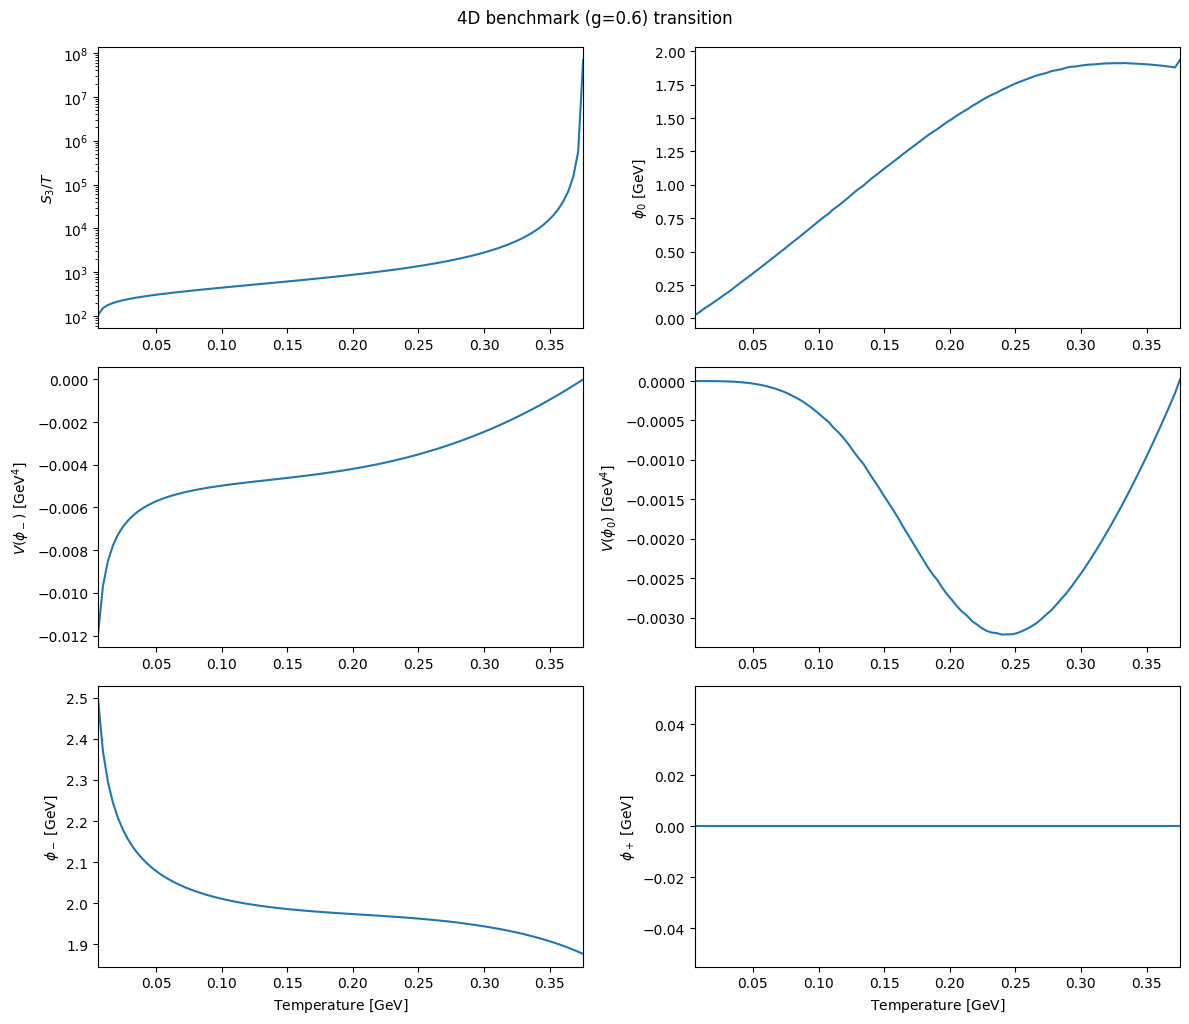

Minimum of the action at T = 5.78e-03 GeV


In [ ]:
import matplotlib.pyplot as plt
import os

if len(temperatures) == 0:
    raise RuntimeError("No temperatures available for plotting.")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

S3_vals      = np.array([S3overT[T] for T in temperatures], dtype=float)
phi0_vals    = np.array([phi0_min[T] for T in temperatures], dtype=float)
Vmin_vals    = np.array([V_min_value[T] for T in temperatures], dtype=float)
Vexit_vals   = np.array([V_exit[T] for T in temperatures], dtype=float)
true_vals    = np.array([true_vev[T] for T in temperatures], dtype=float)
false_vals   = np.array([false_vev[T] for T in temperatures], dtype=float)

axes[0, 0].plot(temperatures, S3_vals)
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, phi0_vals)
axes[0, 1].set_ylabel(f"$\\phi_0\\ \\mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, Vmin_vals)
axes[1, 0].set_ylabel(f"$V(\\phi_-)\\ \\mathrm{{[{units}^4]}}$")

axes[1, 1].plot(temperatures, Vexit_vals)
axes[1, 1].set_ylabel(f"$V(\\phi_0)\\ \\mathrm{{[{units}^4]}}$")

axes[2, 0].plot(temperatures, true_vals)
axes[2, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\\phi_-\\ \\mathrm{{[{units}]}}$")

axes[2, 1].plot(temperatures, false_vals)
axes[2, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\\phi_+\\ \\mathrm{{[{units}]}}$")

for ax in axes.flatten():
    ax.set_xlim(np.min(temperatures), np.max(temperatures))

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.02)

# Save only if figure_dir exists
if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"action_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

T_at_min_action = temperatures[np.argmin(S3_vals)]
print(f"Minimum of the action at T = {T_at_min_action:.2e} {units}")

In [ ]:
from utils import interpolation_narrow
from temperatures import compute_logP_f, N_bubblesH, R_sepH
import numpy as np

is_physical = True

def is_increasing(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) < 2:
        return True
    return np.all(arr[:-1] <= arr[1:])

counter = 0
while counter <= 1:
    # Refined second pass around the milestone region
    if counter == 1:
        if np.isfinite(T_completion) and np.isfinite(T_nuc):
            T_lo = np.nanmax([T_min, 0.95 * T_completion])
            T_hi = np.nanmin([T_max, 1.05 * T_nuc])

            if np.isfinite(T_lo) and np.isfinite(T_hi) and T_hi > T_lo:
                temperatures_refined = np.linspace(T_lo, T_hi, n_points, endpoint=True)
                _ = action_vec(temperatures_refined)

    logP_f, Temps, ratio_V, Gamma, H = compute_logP_f(
        dp,
        V_min_value,
        S3overT,
        v_w=1,
        units=units,
        cum_method='None'
    )

    RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
    nH = N_bubblesH(Temps, Gamma, logP_f, H, ratio_V)

    Temps   = np.asarray(Temps, dtype=float)
    logP_f  = np.asarray(logP_f, dtype=float)
    ratio_V = np.asarray(ratio_V, dtype=float)
    Gamma   = np.asarray(Gamma, dtype=float)
    H       = np.asarray(H, dtype=float)
    nH      = np.asarray(nH, dtype=float)

    # Nucleation: N_bubbles / Hubble volume = 1  -> log(nH)=0
    mask_nH = np.isfinite(nH) & (nH > 0) & np.isfinite(Temps)
    if np.any(mask_nH):
        T_nuc = interpolation_narrow(np.log(nH[mask_nH]), Temps[mask_nH], 0.0)
    else:
        T_nuc = np.nan

    # Percolation/completion from Pf
    mask_Pf = np.isfinite(logP_f) & np.isfinite(Temps)
    if np.any(mask_Pf):
        T_perc = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.71))
        T_completion = interpolation_narrow(logP_f[mask_Pf], Temps[mask_Pf], np.log(0.01))
    else:
        T_perc = np.nan
        T_completion = np.nan

    # Completion sanity check
    if np.isfinite(T_completion):
        idx_compl = int(np.argmin(np.abs(Temps - T_completion)))
        idx_lo = max(idx_compl - 1, 0)
        idx_hi = min(idx_compl + 2, len(Temps))
        test_completion = logP_f[idx_lo:idx_hi]
        test_completion = test_completion[np.isfinite(test_completion)]

        print(counter, T_completion, test_completion)
        print(is_increasing(test_completion))

        if not is_increasing(test_completion):
            T_completion = np.nan
    else:
        print(counter, T_completion, np.array([]))
        print(True)

    # Physical-volume check on second pass
    if counter == 1:
        d_dT_logP_f = np.gradient(logP_f, Temps)

        if np.isfinite(T_perc):
            log_at_T_perc = interpolation_narrow(Temps, d_dT_logP_f, T_perc)
            ratio_V_at_T_perc = interpolation_narrow(Temps, ratio_V, T_perc)

            if np.isfinite(log_at_T_perc) and np.isfinite(ratio_V_at_T_perc):
                if ratio_V_at_T_perc > log_at_T_perc:
                    is_physical = False
                    print("\n*** The physical volume at percolation is not decreasing. The production of GW is questionable. ***")

        if np.isfinite(T_completion):
            log_at_T_completion = interpolation_narrow(Temps, d_dT_logP_f, T_completion)
            ratio_V_at_T_completion = interpolation_narrow(Temps, ratio_V, T_completion)
            # Stored only if you want later inspection

    counter += 1

# Make sure milestone temperatures are in the action dictionaries
milestones = [T_max, T_nuc, T_perc, T_completion, T_min]
milestones = [float(m) for m in milestones if m is not None and np.isfinite(m)]
if len(milestones) > 0:
    _ = action_vec(np.array(milestones, dtype=float))

# For plotting windows
milestone_window = [T_completion, T_perc, T_nuc]
milestone_window = [m for m in milestone_window if np.isfinite(m)]

if len(milestone_window) > 0:
    t_mil_min = np.nanmin(milestone_window)
    t_mil_max = np.nanmax(milestone_window)

    idx_min = max(int(np.argmin(np.abs(Temps - t_mil_min))), 0)
    idx_max = min(int(np.argmin(np.abs(Temps - t_mil_max))), len(Temps) - 1)

    idx_min = idx_min if Temps[idx_min] <= t_mil_min else max(idx_min - 1, 0)
    idx_max = idx_max if Temps[idx_max] >= t_mil_max else min(idx_max + 1, len(Temps) - 1)

    mask = (Temps >= Temps[idx_min]) & (Temps <= Temps[idx_max])
else:
    mask = Temps >= 0

print()
print(f"T_nuc = {T_nuc:.6e} {units}" if np.isfinite(T_nuc) else "T_nuc = nan")
print(f"T_perc = {T_perc:.6e} {units}" if np.isfinite(T_perc) else "T_perc = nan")
print(f"T_completion = {T_completion:.6e} {units}" if np.isfinite(T_completion) else "T_completion = nan")
print()

/content/ELENA/src/temperatures.py:433: RuntimeWarning: divide by zero encountered in power
  return n**(-1/3) * H, n**(-1/3)
/tmp/ipykernel_898/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


0 0.009547615416647132 [-4.75419718e+04 -5.11846079e-07 -9.04649221e-16]
True
1 0.009416132345512163 [-5.68814985 -4.71060746 -3.88066014]
True

T_nuc = 1.097586e-02 GeV
T_perc = 9.750283e-03 GeV
T_completion = 9.416132e-03 GeV



In [ ]:
T_min

np.float64(0.002002578404185474)

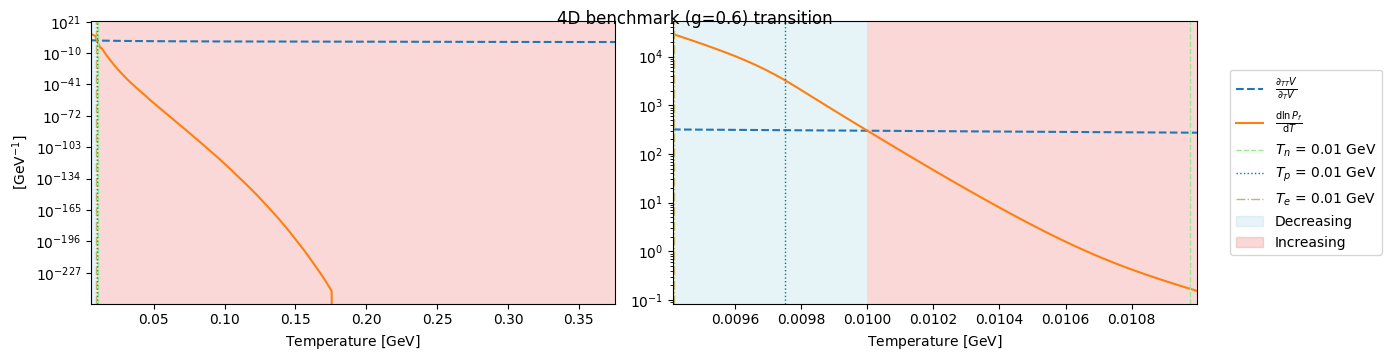

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Basic safety
Temps = np.asarray(Temps, dtype=float)
ratio_V = np.asarray(ratio_V, dtype=float)
d_dT_logP_f = np.asarray(d_dT_logP_f, dtype=float)
mask = np.asarray(mask, dtype=bool)

if len(Temps) < 2:
    raise RuntimeError("Not enough temperature points to make the volume-evolution plot.")

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full-range plot
axes[0].plot(Temps, ratio_V, label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[0].plot(Temps, d_dT_logP_f, label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(f"$\\mathrm{{[{units}^{{-1}}]}}$")

# Zoomed plot
axes[1].plot(Temps[mask], ratio_V[mask], label=r'$\frac{\partial_{TT} V}{\partial_T V}$', linestyle='--')
axes[1].plot(Temps[mask], d_dT_logP_f[mask], label=r'$\frac{\mathrm{d} \ln P_f}{\mathrm{d} T}$')
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# Legend patches
decreasing_patch = mpatches.Patch(color='lightblue', alpha=0.3, label='Decreasing')
increasing_patch = mpatches.Patch(color='lightcoral', alpha=0.3, label='Increasing')

# Find intersections between d_dT_logP_f and ratio_V
intersections = []
diff = d_dT_logP_f - ratio_V

for i in range(len(Temps) - 1):
    y1, y2 = diff[i], diff[i + 1]
    x1, x2 = Temps[i], Temps[i + 1]

    if not (np.isfinite(y1) and np.isfinite(y2) and np.isfinite(x1) and np.isfinite(x2)):
        continue

    # exact hit
    if y1 == 0:
        intersections.append(x1)

    # crossing
    elif y1 * y2 < 0:
        denom = (y2 - y1)
        if denom != 0:
            x_cross = x1 - y1 * (x2 - x1) / denom
            if np.isfinite(x_cross):
                intersections.append(x_cross)

# Add precise crossing points to define colored intervals
all_points = np.sort(np.unique(np.concatenate([Temps, np.array(intersections, dtype=float)])))

for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")

    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}}$ = {T_nuc:.2f} {units}')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}}$ = {T_perc:.2f} {units}')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}}$ = {T_completion:.2f} {units}')

    # Color intervals using midpoint test
    for i in range(len(all_points) - 1):
        x_left, x_right = all_points[i], all_points[i + 1]
        x_mid = 0.5 * (x_left + x_right)

        d_mid = np.interp(x_mid, Temps, d_dT_logP_f)
        r_mid = np.interp(x_mid, Temps, ratio_V)

        if np.isfinite(d_mid) and np.isfinite(r_mid):
            if d_mid >= r_mid:
                ax.axvspan(x_left, x_right, facecolor='lightblue', alpha=0.3)
            else:
                ax.axvspan(x_left, x_right, facecolor='lightcoral', alpha=0.3)

# Put the legend on the right panel
handles, labels = axes[1].get_legend_handles_labels()
handles.extend([decreasing_patch, increasing_patch])
labels.extend(['Decreasing', 'Increasing'])
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

fig.suptitle(f'{description} transition', y=0.89)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"volume_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

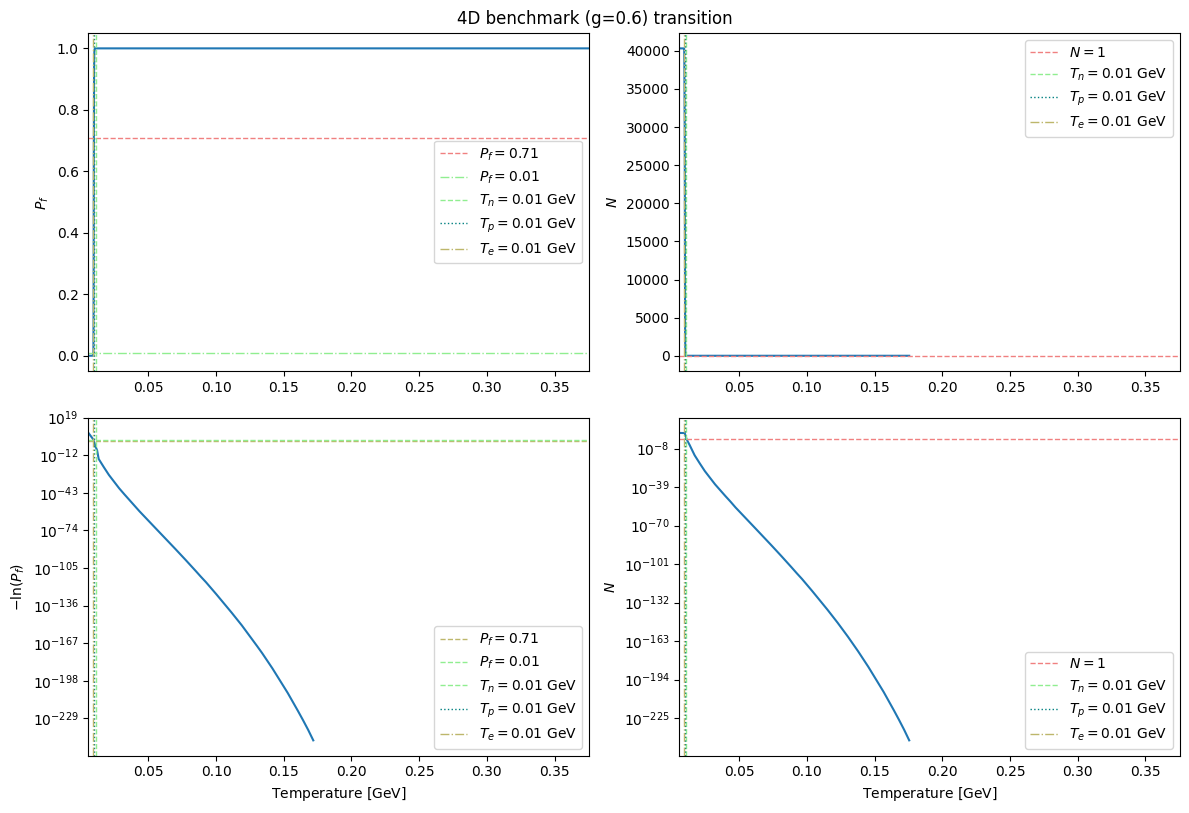

Average number of bubbles at T_min, N = 4.031e+04


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
nH = np.asarray(nH, dtype=float)
mask_nH = np.asarray(mask_nH, dtype=bool)

Pf = np.exp(logP_f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Pf
axes[0, 0].plot(Temps, Pf)
axes[0, 0].set_ylabel(r'$P_f$')
axes[0, 0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[0, 0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=r'$P_f = 0.01$')
axes[0, 0].legend()

# Top-right: N
if np.any(mask_nH):
    axes[0, 1].plot(Temps[mask_nH], nH[mask_nH])
axes[0, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[0, 1].set_ylabel(r'$N$')
axes[0, 1].legend()

# Bottom-left: -ln(Pf)
minus_logPf = -logP_f
mask_log = np.isfinite(minus_logPf) & (minus_logPf > 0)

if np.any(mask_log):
    axes[1, 0].plot(Temps[mask_log], minus_logPf[mask_log])

axes[1, 0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[1, 0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=r'$P_f = 0.01$')
axes[1, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 0].set_ylabel(r'$-\ln(P_f)$')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Bottom-right: N in log scale
mask_nH_log = np.isfinite(nH) & (nH > 0)
if np.any(mask_nH_log):
    axes[1, 1].plot(Temps[mask_nH_log], nH[mask_nH_log])
axes[1, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[1, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 1].set_ylabel(r'$N$')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# Milestone lines
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    ax.set_xlim(Temps[0], Temps[-1])
    ax.legend()

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"evolution_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

if np.any(mask_nH):
    print(f"Average number of bubbles at T_min, N = {nH[mask_nH][0]:.3e}")
else:
    print("Average number of bubbles at T_min, N = nan")

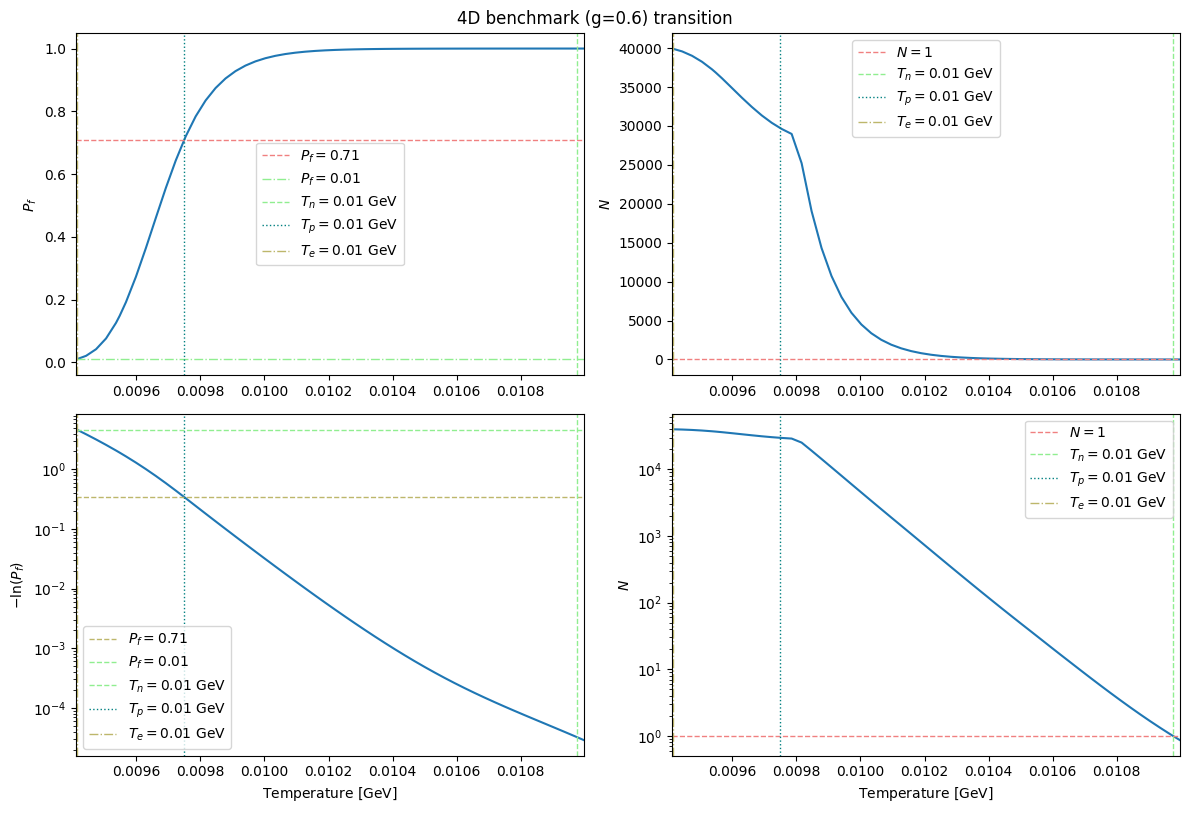

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
nH = np.asarray(nH, dtype=float)
mask = np.asarray(mask, dtype=bool)

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

Temps_zoom = Temps[mask]
logP_f_zoom = logP_f[mask]
nH_zoom = nH[mask]
Pf_zoom = np.exp(logP_f_zoom)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Pf
axes[0, 0].plot(Temps_zoom, Pf_zoom)
axes[0, 0].set_ylabel(r'$P_f$')
axes[0, 0].axhline(0.71, color='lightcoral', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[0, 0].axhline(0.01, color='lightgreen', linestyle='-.', linewidth=1, label=r'$P_f = 0.01$')
axes[0, 0].legend()

# Top-right: N
mask_zoom_nH = np.isfinite(nH_zoom)
if np.any(mask_zoom_nH):
    axes[0, 1].plot(Temps_zoom[mask_zoom_nH], nH_zoom[mask_zoom_nH])
axes[0, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[0, 1].set_ylabel(r'$N$')
axes[0, 1].legend()

# Bottom-left: -ln(Pf)
minus_logPf_zoom = -logP_f_zoom
mask_zoom_log = np.isfinite(minus_logPf_zoom) & (minus_logPf_zoom > 0)
if np.any(mask_zoom_log):
    axes[1, 0].plot(Temps_zoom[mask_zoom_log], minus_logPf_zoom[mask_zoom_log])
axes[1, 0].axhline(-np.log(0.71), color='darkkhaki', linestyle='--', linewidth=1, label=r'$P_f = 0.71$')
axes[1, 0].axhline(-np.log(0.01), color='lightgreen', linestyle='--', linewidth=1, label=r'$P_f = 0.01$')
axes[1, 0].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 0].set_ylabel(r'$-\ln(P_f)$')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()

# Bottom-right: N in log scale
mask_zoom_nH_log = np.isfinite(nH_zoom) & (nH_zoom > 0)
if np.any(mask_zoom_nH_log):
    axes[1, 1].plot(Temps_zoom[mask_zoom_nH_log], nH_zoom[mask_zoom_nH_log])
axes[1, 1].axhline(1.0, color='lightcoral', linestyle='--', linewidth=1, label=r'$N = 1$')
axes[1, 1].set_xlabel(f"$\\mathrm{{Temperature\\ [{units}]}}$")
axes[1, 1].set_ylabel(r'$N$')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()

# Milestone lines
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    ax.set_xlim(Temps_zoom[0], Temps_zoom[-1])
    ax.legend()

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.01)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"evolution_{description}_zoom.pdf"), dpi=300, bbox_inches='tight')

plt.show()

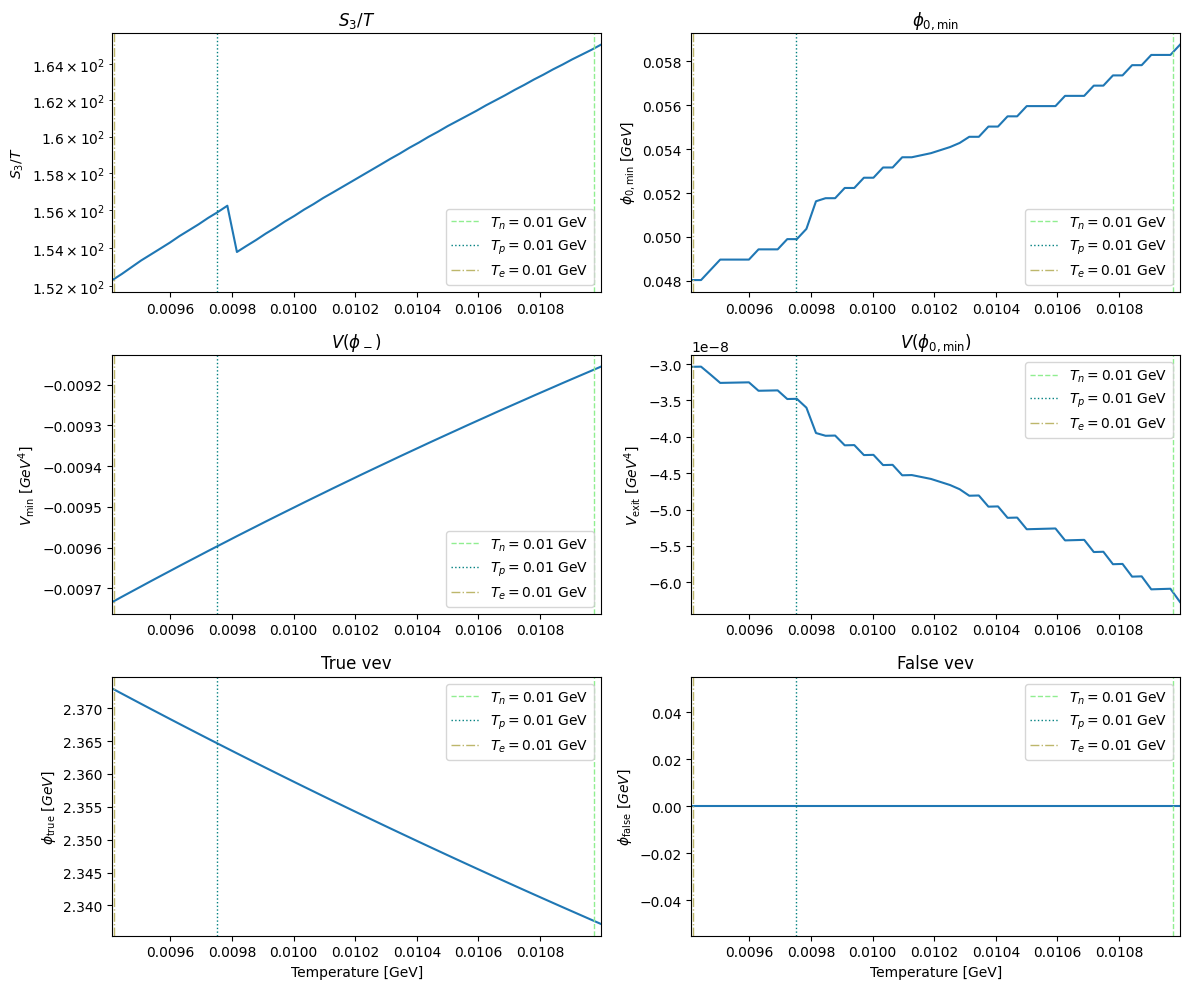

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Temps = np.asarray(Temps, dtype=float)
mask = np.asarray(mask, dtype=bool)

if np.sum(mask) < 2:
    mask = np.ones_like(Temps, dtype=bool)

Temps_zoom = Temps[mask]

# Keep only points that actually exist in the action dictionaries
Temps_zoom = np.array([T for T in Temps_zoom if T in S3overT], dtype=float)

if len(Temps_zoom) == 0:
    raise RuntimeError("No valid zoomed temperatures found in S3overT for plotting.")

S3_vals    = np.array([S3overT[T] for T in Temps_zoom], dtype=float)
phi0_vals  = np.array([phi0_min[T] for T in Temps_zoom], dtype=float)
Vmin_vals  = np.array([V_min_value[T] for T in Temps_zoom], dtype=float)
Vexit_vals = np.array([V_exit[T] for T in Temps_zoom], dtype=float)
true_vals  = np.array([true_vev[T] for T in Temps_zoom], dtype=float)
false_vals = np.array([false_vev[T] for T in Temps_zoom], dtype=float)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(Temps_zoom, S3_vals)
axes[0, 0].set_title(r'$S_3/T$')
axes[0, 0].set_ylabel(r'$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(Temps_zoom, phi0_vals)
axes[0, 1].set_title(r'$\phi_{0,\mathrm{min}}$')
axes[0, 1].set_ylabel(f"$\\phi_{{0,\\mathrm{{min}}}}\\ [{units}]$")

axes[1, 0].plot(Temps_zoom, Vmin_vals)
axes[1, 0].set_title(r'$V(\phi_-)$')
axes[1, 0].set_ylabel(f"$V_{{\\mathrm{{min}}}}\\ [{units}^4]$")

axes[1, 1].plot(Temps_zoom, Vexit_vals)
axes[1, 1].set_title(r'$V(\phi_{0,\mathrm{min}})$')
axes[1, 1].set_ylabel(f"$V_{{\\mathrm{{exit}}}}\\ [{units}^4]$")

axes[2, 0].plot(Temps_zoom, true_vals)
axes[2, 0].set_title('True vev')
axes[2, 0].set_xlabel(f"Temperature [{units}]")
axes[2, 0].set_ylabel(f"$\\phi_{{\\mathrm{{true}}}}\\ [{units}]$")

axes[2, 1].plot(Temps_zoom, false_vals)
axes[2, 1].set_title('False vev')
axes[2, 1].set_xlabel(f"Temperature [{units}]")
axes[2, 1].set_ylabel(f"$\\phi_{{\\mathrm{{false}}}}\\ [{units}]$")

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_{{n}} = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_{{p}} = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_{{e}} = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    ax.set_xlim(Temps_zoom[0], Temps_zoom[-1])
    ax.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_898/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


c_s^2(T_perc) = -0.8121824977041268


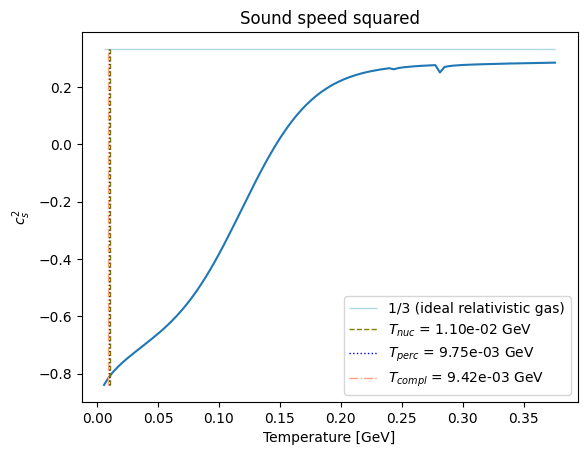

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def cs2_fixed(T_val, model_instance, true_vev_dict, units='GeV'):
    T_val = float(T_val)

    if T_val not in true_vev_dict:
        return np.nan

    phi_val = float(true_vev_dict[T_val])
    phi_val_array = np.array([[phi_val]], dtype=float)

    try:
        dVdT_val = model_instance.dVdT(
            phi_val_array, T_val,
            include_radiation=True,
            include_SM=True,
            units=units
        )
        d2VdT2_val = model_instance.d2VdT2(
            phi_val_array, T_val,
            include_radiation=True,
            include_SM=True,
            units=units
        )

        dVdT_val = float(np.asarray(dVdT_val).squeeze())
        d2VdT2_val = float(np.asarray(d2VdT2_val).squeeze())

        if T_val == 0.0 or d2VdT2_val == 0.0 or not np.isfinite(d2VdT2_val):
            return np.nan

        speed2 = dVdT_val / (T_val * d2VdT2_val)

        if not np.isfinite(speed2):
            return np.nan

        return min(1.0 / 3.0, speed2)

    except Exception:
        return np.nan

# Make sure T_perc action point exists
if np.isfinite(T_perc):
    _ = action_over_T(T_perc)
    c_s2 = cs2_fixed(T_perc, dp, true_vev, units=units)
    print(f"c_s^2(T_perc) = {c_s2}")
else:
    c_s2 = np.nan

# Evaluate only where true_vev exists
Temps_cs = np.array([float(T) for T in Temps if T in true_vev], dtype=float)
y = np.array([cs2_fixed(T, dp, true_vev, units=units) for T in Temps_cs], dtype=float)

plt.plot(Temps_cs, y)
plt.hlines(
    1/3,
    Temps_cs[0], Temps_cs[-1],
    color='lightblue',
    linestyle='-',
    linewidth=1,
    label='1/3 (ideal relativistic gas)'
)

ymin = np.nanmin(y) if np.any(np.isfinite(y)) else 0.0
ymax = np.nanmax([np.nanmax(y[np.isfinite(y)]) if np.any(np.isfinite(y)) else 0.0, (1 + 1e-4) / 3.0])

if np.isfinite(T_nuc):
    plt.vlines(T_nuc, ymin, ymax, color='olive', linestyle='--', linewidth=1,
               label=f'$T_{{nuc}}$ = {T_nuc:.2e} {units}')
if np.isfinite(T_perc):
    plt.vlines(T_perc, ymin, ymax, color='blue', linestyle=':', linewidth=1,
               label=f'$T_{{perc}}$ = {T_perc:.2e} {units}')
if np.isfinite(T_completion):
    plt.vlines(T_completion, ymin, ymax, color='lightsalmon', linestyle='-.', linewidth=1,
               label=f'$T_{{compl}}$ = {T_completion:.2e} {units}')

plt.title('Sound speed squared')
plt.xlabel(f'Temperature [{units}]')
plt.ylabel(r'$c_s^2$')
plt.legend()
plt.show()

In [ ]:
import numpy as np

def _to_scalar(x):
    arr = np.asarray(x, dtype=float)
    return float(arr.reshape(-1)[0])

def c_alpha_inf(T, dp, true_vev_dict, false_vev_dict, units='GeV'):
    T = float(T)

    if T not in true_vev_dict or T not in false_vev_dict:
        return np.nan, np.nan

    v_true_arr = np.array([[float(true_vev_dict[T])]], dtype=float)
    v_false_arr = np.array([[float(false_vev_dict[T])]], dtype=float)

    # Running parameters at mu = mu_eff(T)
    mu = dp.mu_eff(T)
    g2, lam, m2 = dp.run_params(mu)

    # Your current paper-model code only has bosons, so keep the same structure
    Dm2_photon = 3.0 * g2 * (v_true_arr**2 - v_false_arr**2)
    Dm2_scalar = 3.0 * lam * (v_true_arr**2 - v_false_arr**2)
    numerator = _to_scalar((Dm2_photon + Dm2_scalar) * T**2 / 24.0)

    rho_tot = -T * 3.0 * _to_scalar(
        dp.dVdT(v_false_arr, T, include_radiation=True, include_SM=True, units=units)
    ) / 4.0
    rho_DS = -T * 3.0 * _to_scalar(
        dp.dVdT(v_false_arr, T, include_radiation=True, include_SM=False, units=units)
    ) / 4.0

    alpha_inf_tot = np.nan if (not np.isfinite(rho_tot) or rho_tot <= 0.0) else numerator / rho_tot
    alpha_inf_DS  = np.nan if (not np.isfinite(rho_DS)  or rho_DS  <= 0.0) else numerator / rho_DS

    return alpha_inf_tot, alpha_inf_DS


def c_alpha_eq(T, dp, true_vev_dict, false_vev_dict, units='GeV'):
    T = float(T)

    if T not in true_vev_dict or T not in false_vev_dict:
        return np.nan, np.nan

    v_true_arr = np.array([[float(true_vev_dict[T])]], dtype=float)
    v_false_arr = np.array([[float(false_vev_dict[T])]], dtype=float)

    # Running parameters at mu = mu_eff(T)
    mu = dp.mu_eff(T)
    g2, lam, m2 = dp.run_params(mu)
    g = np.sqrt(max(g2, 0.0))

    numerator = _to_scalar(g2 * 3.0 * (g * (v_true_arr - v_false_arr)) * T**3)

    rho_tot = -T * 3.0 * _to_scalar(
        dp.dVdT(v_false_arr, T, include_radiation=True, include_SM=True, units=units)
    ) / 4.0
    rho_DS = -T * 3.0 * _to_scalar(
        dp.dVdT(v_false_arr, T, include_radiation=True, include_SM=False, units=units)
    ) / 4.0

    alpha_eq_tot = np.nan if (not np.isfinite(rho_tot) or rho_tot <= 0.0) else numerator / rho_tot
    alpha_eq_DS  = np.nan if (not np.isfinite(rho_DS)  or rho_DS  <= 0.0) else numerator / rho_DS

    return alpha_eq_tot, alpha_eq_DS

In [ ]:
import numpy as np

def _to_scalar(x):
    arr = np.asarray(x, dtype=float)
    return float(arr.reshape(-1)[0])

def cs2_fixed(T_val, model_instance, true_vev_dict, units='GeV'):
    T_val = float(T_val)

    if T_val not in true_vev_dict:
        return np.nan

    phi_val_array = np.array([[float(true_vev_dict[T_val])]], dtype=float)

    try:
        dVdT_val = _to_scalar(
            model_instance.dVdT(
                phi_val_array, T_val,
                include_radiation=True,
                include_SM=True,
                units=units
            )
        )
        d2VdT2_val = _to_scalar(
            model_instance.d2VdT2(
                phi_val_array, T_val,
                include_radiation=True,
                include_SM=True,
                units=units
            )
        )
    except Exception:
        return np.nan

    if (
        T_val == 0.0
        or d2VdT2_val == 0.0
        or not np.isfinite(d2VdT2_val)
    ):
        return np.nan

    speed2 = dVdT_val / (T_val * d2VdT2_val)

    if not np.isfinite(speed2):
        return np.nan

    return min(1.0 / 3.0, speed2)


def cs2_fixed_DS(T_val, model_instance, true_vev_dict, units='GeV'):
    T_val = float(T_val)

    if T_val not in true_vev_dict:
        return np.nan

    phi_val_array = np.array([[float(true_vev_dict[T_val])]], dtype=float)

    try:
        dVdT_val = _to_scalar(
            model_instance.dVdT(
                phi_val_array, T_val,
                include_radiation=True,
                include_SM=False,
                units=units
            )
        )
        d2VdT2_val = _to_scalar(
            model_instance.d2VdT2(
                phi_val_array, T_val,
                include_radiation=True,
                include_SM=False,
                units=units
            )
        )
    except Exception:
        return np.nan

    if (
        T_val == 0.0
        or d2VdT2_val == 0.0
        or not np.isfinite(d2VdT2_val)
    ):
        return np.nan

    speed2 = dVdT_val / (T_val * d2VdT2_val)

    if not np.isfinite(speed2):
        return np.nan

    return min(1.0 / 3.0, speed2)


def alpha_th_bar_fixed(T, m, V_min_value_dict, false_vev_dict, true_vev_dict, units='GeV'):
    T = float(T)

    if T not in V_min_value_dict or T not in false_vev_dict or T not in true_vev_dict:
        return np.nan, np.nan

    false_vev_T_arr = np.array([[float(false_vev_dict[T])]], dtype=float)
    true_vev_T_arr  = np.array([[float(true_vev_dict[T])]], dtype=float)

    Vmin_T = float(V_min_value_dict[T])

    # -------- total sector --------
    dV_false_tot = _to_scalar(
        m.dVdT(false_vev_T_arr, T, include_radiation=True, include_SM=True, units=units)
    )
    dV_true_tot = _to_scalar(
        m.dVdT(true_vev_T_arr, T, include_radiation=True, include_SM=True, units=units)
    )

    delta_rho_tot = -Vmin_T - T * (dV_false_tot - dV_true_tot)

    c_s2_tot = cs2_fixed(T, m, true_vev_dict, units=units)
    if not np.isfinite(c_s2_tot) or c_s2_tot == 0.0:
        delta_p_tot = np.nan
    else:
        delta_p_tot = Vmin_T / c_s2_tot

    wf_tot = -T * dV_false_tot
    w_th_tot = -T * dV_true_tot
    denom_tot = wf_tot - w_th_tot

    if not np.isfinite(delta_p_tot) or not np.isfinite(denom_tot) or denom_tot == 0.0:
        alpha_val = np.nan
    else:
        alpha_val = (delta_rho_tot - delta_p_tot) / denom_tot

    # -------- dark sector only --------
    dV_false_DS = _to_scalar(
        m.dVdT(false_vev_T_arr, T, include_radiation=True, include_SM=False, units=units)
    )
    dV_true_DS = _to_scalar(
        m.dVdT(true_vev_T_arr, T, include_radiation=True, include_SM=False, units=units)
    )

    delta_rho_DS = -Vmin_T - T * (dV_false_DS - dV_true_DS)

    c_s2_DS_val = cs2_fixed_DS(T, m, true_vev_dict, units=units)
    if not np.isfinite(c_s2_DS_val) or c_s2_DS_val == 0.0:
        delta_p_DS_val = np.nan
    else:
        delta_p_DS_val = Vmin_T / c_s2_DS_val

    wf_DS = -T * dV_false_DS
    w_th_DS = -T * dV_true_DS
    denom_DS = wf_DS - w_th_DS

    if not np.isfinite(delta_p_DS_val) or not np.isfinite(denom_DS) or denom_DS == 0.0:
        alpha_DS_val = np.nan
    else:
        alpha_DS_val = (delta_rho_DS - delta_p_DS_val) / denom_DS

    return alpha_val, alpha_DS_val


# ---- evaluate at percolation ----
if np.isfinite(T_perc):
    _ = action_over_T(T_perc)

    alpha, alpha_DS = alpha_th_bar_fixed(
        T_perc, dp, V_min_value, false_vev, true_vev, units=units
    )
    alpha_inf, alpha_inf_DS = c_alpha_inf(
        T_perc, dp, true_vev, false_vev, units=units
    )
    alpha_eq, alpha_eq_DS = c_alpha_eq(
        T_perc, dp, true_vev, false_vev, units=units
    )
else:
    alpha = alpha_DS = np.nan
    alpha_inf = alpha_inf_DS = np.nan
    alpha_eq = alpha_eq_DS = np.nan

if not np.isfinite(alpha) or not np.isfinite(alpha_inf) or not np.isfinite(alpha_eq) or alpha_eq == 0.0:
    gamma_eq = np.nan
else:
    gamma_eq = (alpha - alpha_inf) / alpha_eq

print(f"alpha = {alpha}")
print(f"alpha_DS = {alpha_DS}")
print(f"alpha_inf = {alpha_inf}")
print(f"alpha_inf_DS = {alpha_inf_DS}")
print(f"alpha_eq = {alpha_eq}")
print(f"alpha_eq_DS = {alpha_eq_DS}")
print(f"gamma_eq = {gamma_eq}")

is_physical = True

if np.isfinite(alpha) and np.isfinite(alpha_inf):
    if alpha < alpha_inf:
        is_physical = False
        print("\n*** Warning: the bubble expansion is not in the runaway regime. The results may not be reliable. ***")
else:
    is_physical = False
    print("\n*** Warning: alpha or alpha_inf could not be computed reliably. ***")

v_min = 0.99
gamma_limit = 1.0 / np.sqrt(1.0 - v_min**2)

if np.isfinite(gamma_eq):
    if gamma_eq < gamma_limit:
        is_physical = False
        print(
            f"\n*** Warning: the NLO pressure could prevent the walls from reaching relativistic velocities "
            f"(gamma_eq = {gamma_eq:.2e}). The results may not be reliable. ***"
        )
else:
    is_physical = False
    print("\n*** Warning: gamma_eq could not be computed reliably. The results may not be reliable. ***")

alpha = 0.4171029722393213
alpha_DS = 0.4171029722393213
alpha_inf = 1513.7198497951376
alpha_inf_DS = 1513.7198497951376
alpha_eq = 94.37288118570712
alpha_eq_DS = 94.37288118570712
gamma_eq = -16.035356002801468

*** Warning: the bubble expansion is not in the runaway regime. The results may not be reliable. ***

*** Warning: the NLO pressure could prevent the walls from reaching relativistic velocities (gamma_eq = -1.60e+01). The results may not be reliable. ***


/tmp/ipykernel_898/4012610694.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_exit[T] = float(instance.V_exit)


In [ ]:
import numpy as np

def alpha_MSbar(dp, T, true_vev, false_vev, gstar=100.0, units='GeV'):
    """
    Computes the correct thermodynamic alpha for the MS-bar 4D model (Code B).

    Parameters
    ----------
    dp          : instance of AbelianHiggsMSbarPaper
    T           : percolation (or nucleation) temperature
    true_vev    : dictionary {T: phi_true(T)}
    false_vev   : dictionary {T: phi_false(T)}   (typically 0)
    gstar       : relativistic degrees of freedom
    units       : energy units (unused but kept for consistency)

    Returns
    -------
    alpha : float
        The correct thermodynamic strength parameter α(T).
    """

    T = float(T)

    if T not in true_vev or T not in false_vev:
        return np.nan

    # Field values at minima
    phi_true  = np.array([[float(true_vev[T])]],  dtype=float)
    phi_false = np.array([[float(false_vev[T])]], dtype=float)

    # Effective potential values
    V_true  = float(dp.Vtot(phi_true,  T, include_radiation=True))
    V_false = float(dp.Vtot(phi_false, T, include_radiation=True))

    # Potential difference
    DeltaV = V_false - V_true

    # dV/dT at minima
    dVdT_true  = float(dp.dVdT(phi_true,  T, include_radiation=True, include_SM=True))
    dVdT_false = float(dp.dVdT(phi_false, T, include_radiation=True, include_SM=True))

    # Derivative difference
    Delta_dVdT = dVdT_false - dVdT_true

    # Radiation energy density
    rho_rad = (np.pi**2 / 30.0) * gstar * (T**4)

    # Alpha (thermodynamic strength)
    alpha = (DeltaV - T * Delta_dVdT) / rho_rad

    return alpha

In [ ]:
alpha_val = alpha_MSbar(dp, T_perc, true_vev, false_vev, gstar=100)
print("alpha =", alpha_val)

alpha = 45084.77085084483


In [ ]:
import numpy as np

def beta_over_H(dp, T_star, action_over_T_func, dT=1e-2):
    """
    Correct and numerically robust computation of beta/H for the MS-bar 4D model (Code B).
    Uses central differences when possible, otherwise falls back to one-sided differences.
    """

    T_star = float(T_star)

    # Evaluate S3/T at T_star
    S0 = action_over_T_func(T_star)
    if S0 is None or not np.isfinite(S0):
        raise RuntimeError(f"S3/T could not be computed at T = {T_star}")

    # Try forward and backward evaluations
    Sp = action_over_T_func(T_star + dT)
    Sm = action_over_T_func(T_star - dT)

    # CASE 1: Central difference OK
    if Sp is not None and Sm is not None and np.isfinite(Sp) and np.isfinite(Sm):
        dSdT = (Sp - Sm) / (2 * dT)
        return T_star * dSdT

    # CASE 2: Forward difference only
    if Sp is not None and np.isfinite(Sp):
        dSdT = (Sp - S0) / dT
        return T_star * dSdT

    # CASE 3: Backward difference only
    if Sm is not None and np.isfinite(Sm):
        dSdT = (S0 - Sm) / dT
        return T_star * dSdT

    # CASE 4: Total failure
    raise RuntimeError(
        f"S3/T failed at T={T_star} ± {dT}. "
        "Bounce solver did not converge."
    )

In [ ]:
beta_H = beta_over_H(dp, T_perc, action_over_T)
print("beta/H =", beta_H)

beta/H = 54.43383811178821


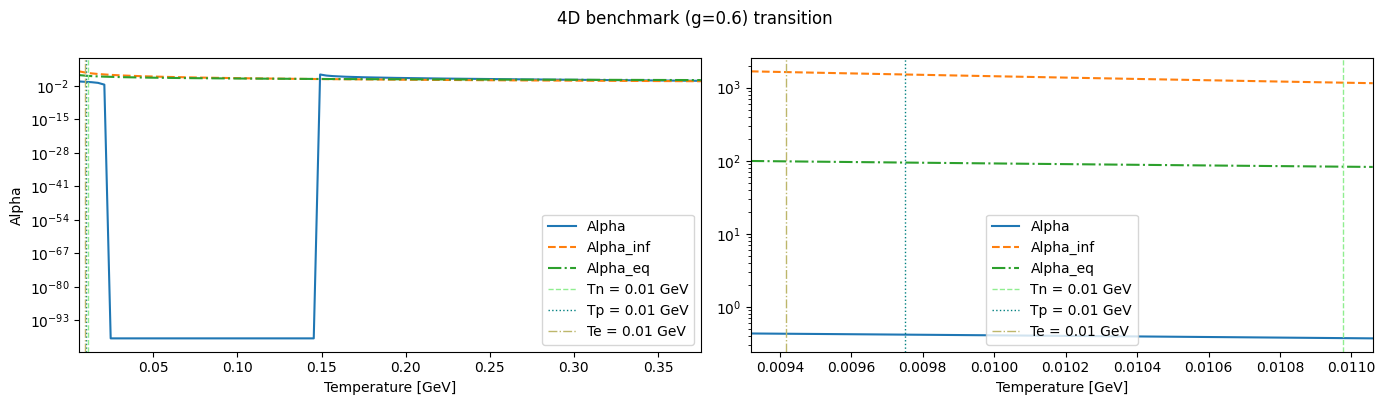

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['text.usetex'] = False

def alpha_th_bar_fixed(T, m, V_min_value_dict, false_vev_dict, true_vev_dict, units='GeV'):
    T = float(T)

    if T not in V_min_value_dict or T not in false_vev_dict or T not in true_vev_dict:
        return np.nan, np.nan

    false_vev_T_arr = np.array([[float(false_vev_dict[T])]], dtype=float)
    true_vev_T_arr  = np.array([[float(true_vev_dict[T])]], dtype=float)

    Vmin_T = float(V_min_value_dict[T])

    # total sector
    dV_false_tot = _to_scalar(
        m.dVdT(false_vev_T_arr, T, include_radiation=True, include_SM=True, units=units)
    )
    dV_true_tot = _to_scalar(
        m.dVdT(true_vev_T_arr, T, include_radiation=True, include_SM=True, units=units)
    )

    delta_rho_tot = -Vmin_T - T * (dV_false_tot - dV_true_tot)
    c_s2_tot = cs2_fixed(T, m, true_vev_dict, units=units)

    if not np.isfinite(c_s2_tot) or c_s2_tot == 0.0:
        delta_p_tot = np.nan
    else:
        delta_p_tot = Vmin_T / c_s2_tot

    wf_tot = -T * dV_false_tot
    w_th_tot = -T * dV_true_tot
    denom_tot = wf_tot - w_th_tot

    if not np.isfinite(delta_p_tot) or not np.isfinite(denom_tot) or denom_tot == 0.0:
        alpha_val = np.nan
    else:
        alpha_val = (delta_rho_tot - delta_p_tot) / denom_tot

    # dark sector only
    dV_false_DS = _to_scalar(
        m.dVdT(false_vev_T_arr, T, include_radiation=True, include_SM=False, units=units)
    )
    dV_true_DS = _to_scalar(
        m.dVdT(true_vev_T_arr, T, include_radiation=True, include_SM=False, units=units)
    )

    delta_rho_DS = -Vmin_T - T * (dV_false_DS - dV_true_DS)
    c_s2_DS_val = cs2_fixed_DS(T, m, true_vev_dict, units=units)

    if not np.isfinite(c_s2_DS_val) or c_s2_DS_val == 0.0:
        delta_p_DS_val = np.nan
    else:
        delta_p_DS_val = Vmin_T / c_s2_DS_val

    wf_DS = -T * dV_false_DS
    w_th_DS = -T * dV_true_DS
    denom_DS = wf_DS - w_th_DS

    if not np.isfinite(delta_p_DS_val) or not np.isfinite(denom_DS) or denom_DS == 0.0:
        alpha_DS_val = np.nan
    else:
        alpha_DS_val = (delta_rho_DS - delta_p_DS_val) / denom_DS

    return alpha_val, alpha_DS_val


Temps = np.asarray(Temps, dtype=float)

# Use only temperatures where all required dictionaries are present
Temps_alpha = np.array(
    [float(T) for T in Temps if T in V_min_value and T in false_vev and T in true_vev],
    dtype=float
)

if len(Temps_alpha) == 0:
    raise RuntimeError("No valid temperatures available to build alpha(T).")

alpha_T = np.array(
    [alpha_th_bar_fixed(T, dp, V_min_value, false_vev, true_vev, units=units)[0] for T in Temps_alpha],
    dtype=float
)
alpha_inf_T = np.array(
    [c_alpha_inf(T, dp, true_vev, false_vev, units=units)[0] for T in Temps_alpha],
    dtype=float
)
alpha_eq_T = np.array(
    [c_alpha_eq(T, dp, true_vev, false_vev, units=units)[0] for T in Temps_alpha],
    dtype=float
)

# Build zoom mask around milestones
milestones_alpha = [T_completion, T_perc, T_nuc]
milestones_alpha = [m for m in milestones_alpha if np.isfinite(m)]

if len(milestones_alpha) == 0:
    mask_alpha = np.ones_like(Temps_alpha, dtype=bool)
else:
    t_mil_min = np.nanmin(milestones_alpha)
    t_mil_max = np.nanmax(milestones_alpha)
    i0 = max(int(np.argmin(np.abs(Temps_alpha - t_mil_min))) - 3, 0)
    i1 = min(int(np.argmin(np.abs(Temps_alpha - t_mil_max))) + 3, len(Temps_alpha) - 1)
    mask_alpha = np.zeros_like(Temps_alpha, dtype=bool)
    mask_alpha[i0:i1+1] = True

plot_floor = 1e-100

def _log_plot_safe(arr):
    arr = np.asarray(arr, dtype=float).copy()
    arr[~np.isfinite(arr)] = plot_floor
    arr[arr <= 0] = plot_floor
    return arr

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full range
axes[0].plot(Temps_alpha, _log_plot_safe(alpha_T), linestyle='-',  label='Alpha')
axes[0].plot(Temps_alpha, _log_plot_safe(alpha_inf_T), linestyle='--', label='Alpha_inf')
axes[0].plot(Temps_alpha, _log_plot_safe(alpha_eq_T), linestyle='-.', label='Alpha_eq')
axes[0].set_xlabel(f"Temperature [{units}]")
axes[0].set_ylabel('Alpha')
axes[0].set_yscale('log')
axes[0].set_xlim(Temps_alpha[0], Temps_alpha[-1])

if np.isfinite(T_nuc):
    axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'Tn = {T_nuc:.2f} {units}')
if np.isfinite(T_perc):
    axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'Tp = {T_perc:.2f} {units}')
if np.isfinite(T_completion):
    axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'Te = {T_completion:.2f} {units}')
axes[0].legend()

# Zoom
Temps_alpha_zoom = Temps_alpha[mask_alpha]
alpha_zoom = _log_plot_safe(alpha_T[mask_alpha])
alpha_inf_zoom = _log_plot_safe(alpha_inf_T[mask_alpha])
alpha_eq_zoom = _log_plot_safe(alpha_eq_T[mask_alpha])

axes[1].plot(Temps_alpha_zoom, alpha_zoom, linestyle='-', label='Alpha')
axes[1].plot(Temps_alpha_zoom, alpha_inf_zoom, linestyle='--', label='Alpha_inf')
axes[1].plot(Temps_alpha_zoom, alpha_eq_zoom, linestyle='-.', label='Alpha_eq')
axes[1].set_xlabel(f"Temperature [{units}]")
axes[1].set_xlim(Temps_alpha_zoom[0], Temps_alpha_zoom[-1])

y_data_masked = np.concatenate([alpha_zoom.flatten(), alpha_inf_zoom.flatten(), alpha_eq_zoom.flatten()])
y_data_masked_positive = y_data_masked[y_data_masked > plot_floor]

if len(y_data_masked_positive) > 1 and np.nanmax(y_data_masked_positive) > np.nanmin(y_data_masked_positive):
    axes[1].set_yscale('log')
else:
    axes[1].set_yscale('linear')
    axes[1].set_ylim(bottom=0)

if np.isfinite(T_nuc):
    axes[1].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'Tn = {T_nuc:.2f} {units}')
if np.isfinite(T_perc):
    axes[1].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'Tp = {T_perc:.2f} {units}')
if np.isfinite(T_completion):
    axes[1].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'Te = {T_completion:.2f} {units}')
axes[1].legend()

fig.suptitle(f'{description} transition', y=1.00)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"alpha_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from temperatures import R_sepH
import numpy as np

Temps = np.asarray(Temps, dtype=float)
Gamma = np.asarray(Gamma, dtype=float)
logP_f = np.asarray(logP_f, dtype=float)
H = np.asarray(H, dtype=float)
ratio_V = np.asarray(ratio_V, dtype=float)

RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)

RH = np.asarray(RH, dtype=float)
R = np.asarray(R, dtype=float)

if np.isfinite(T_perc):
    RH_interp = np.interp(T_perc, Temps, RH)
    H_star = np.interp(T_perc, Temps, H)

    if np.isfinite(H_star) and H_star != 0.0:
        R_star = RH_interp / H_star
    else:
        R_star = np.nan

    print(f"R* H* = {RH_interp:.2e}")
    print(f"H* = {H_star:.2e}")
    print(f"R* = {R_star:.2e} [{units}^-1]")
else:
    RH_interp = np.nan
    H_star = np.nan
    R_star = np.nan
    print("R* H* = nan")

R* H* = 5.30e-02
H* = 2.32e-20
R* = 2.28e+18 [GeV^-1]


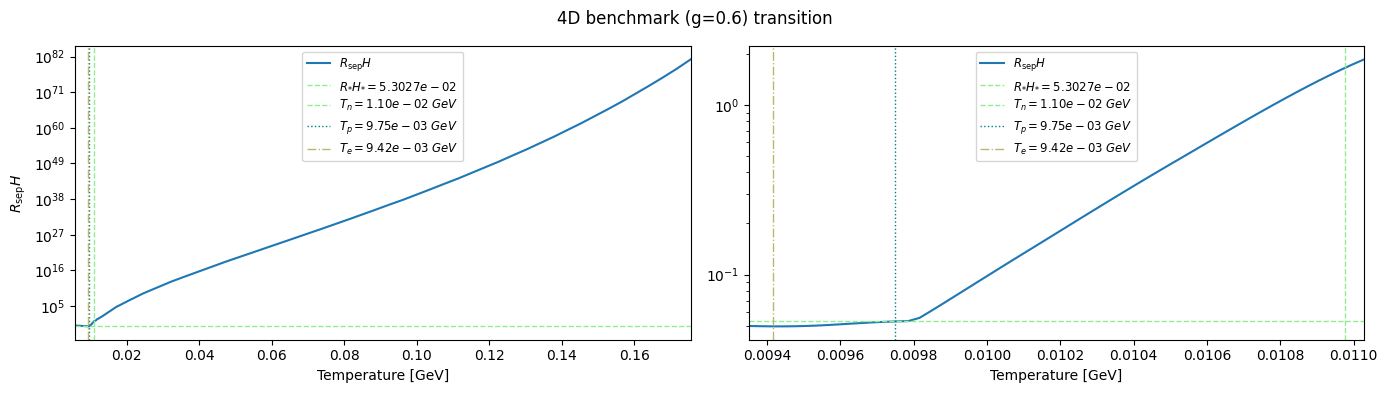

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

Temps = np.asarray(Temps, dtype=float)
RH = np.asarray(RH, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ---------- full plot ----------
mask_finite_RH = np.isfinite(RH)
if np.any(mask_finite_RH):
    axes[0].plot(Temps[mask_finite_RH], RH[mask_finite_RH], label=r'$R_{\rm sep} H$')
else:
    axes[0].set_title("No finite RH data")

axes[0].set_ylabel(r'$R_{\rm sep} H$')
axes[0].set_yscale('log')

if np.isfinite(RH_interp):
    axes[0].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1,
                    label=f'$R_{{*}}H_{{*}} = {RH_interp:.4e}$')

if np.any(mask_finite_RH):
    axes[0].set_xlim(Temps[0], Temps[np.where(mask_finite_RH)[0][-1]])

# ---------- zoom plot ----------
milestones_plot = [T_completion, T_perc, T_nuc]
milestones_plot = [m for m in milestones_plot if np.isfinite(m)]

if len(milestones_plot) > 0:
    t_mil_min_plot = np.nanmin(milestones_plot)
    t_mil_max_plot = np.nanmax(milestones_plot)
    padding = 0.05 * (t_mil_max_plot - t_mil_min_plot)
else:
    t_mil_min_plot = Temps[0]
    t_mil_max_plot = Temps[-1]
    padding = 0.05 * (Temps[-1] - Temps[0])

if not np.isfinite(padding) or padding == 0:
    padding = 0.05 * max(Temps[-1] - Temps[0], 1.0)

mask_RH_zoom = (Temps >= t_mil_min_plot - padding) & (Temps <= t_mil_max_plot + padding) & np.isfinite(RH)

if not np.any(mask_RH_zoom) and Temps.size > 0:
    center_T = T_perc if np.isfinite(T_perc) else np.mean(Temps)
    range_T = Temps[-1] - Temps[0]
    if range_T == 0:
        mask_RH_zoom = (Temps == center_T) & np.isfinite(RH)
    else:
        mask_RH_zoom = (Temps >= center_T - 0.1 * range_T) & (Temps <= center_T + 0.1 * range_T) & np.isfinite(RH)

if not np.any(mask_RH_zoom):
    mask_RH_zoom = np.isfinite(RH)

if np.any(mask_RH_zoom):
    axes[1].plot(Temps[mask_RH_zoom], RH[mask_RH_zoom], label=r'$R_{\rm sep} H$')
    axes[1].set_yscale('log')
    if np.isfinite(RH_interp):
        axes[1].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1,
                        label=f'$R_{{*}}H_{{*}} = {RH_interp:.4e}$')
    axes[1].set_xlim(Temps[mask_RH_zoom][0], Temps[mask_RH_zoom][-1])
    axes[1].legend()
else:
    axes[1].set_title("No data in masked range")

# ---------- milestone lines ----------
for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_n = {T_nuc:.2e}\\ {units}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_p = {T_perc:.2e}\\ {units}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_e = {T_completion:.2e}\\ {units}$')
    ax.set_xlabel(f"Temperature [{units}]")
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), fontsize='small')

fig.suptitle(f'{description} transition', y=0.97)

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, "RH_transition.pdf"), dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [ ]:
T_perc

np.float64(0.009750283278917355)

/content/ELENA/src/temperatures.py:439: RuntimeWarning: invalid value encountered in scalar power
  r0 = ((3 * E0V / (4*np.pi*DV))**(1/3.0))
/tmp/ipykernel_898/3505343340.py:23: RuntimeWarning: invalid value encountered in scalar power
  r0 = (3.0 * E0V / (4.0 * np.pi * DV)) ** (1.0 / 3.0)


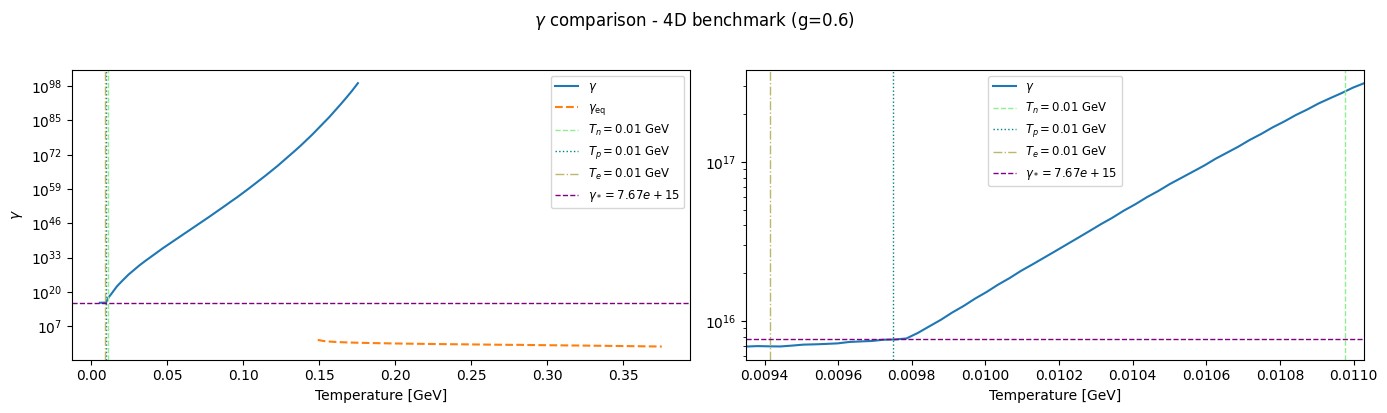

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from temperatures import R0 as ELENA_R0

plt.rcParams['text.usetex'] = False

def R0_safe(T, S3overT_dict, V_exit_dict):
    """
    Safe wrapper around ELENA's R0.
    Handles both scalar and array-like returns.
    """
    try:
        val = ELENA_R0(T, S3overT_dict, V_exit_dict)
        arr = np.asarray(val, dtype=float)
        if arr.shape == ():
            return float(arr)
        return float(arr.reshape(-1)[0])
    except IndexError:
        # Reproduce ELENA formula manually if its internal return indexing fails
        E0V = 3.0 * S3overT_dict[T] * T / 4.0
        DV = -V_exit_dict[T]
        r0 = (3.0 * E0V / (4.0 * np.pi * DV)) ** (1.0 / 3.0)
        arr = np.asarray(r0, dtype=float)
        if arr.shape == ():
            return float(arr)
        return float(arr.reshape(-1)[0])

Temps = np.asarray(Temps, dtype=float)
RH = np.asarray(RH, dtype=float)
R = np.asarray(R, dtype=float)
H = np.asarray(H, dtype=float)

Temps_gamma = np.array(
    [float(T) for T in Temps if T in S3overT and T in V_exit and T in V_min_value and T in false_vev and T in true_vev],
    dtype=float
)

if len(Temps_gamma) == 0:
    raise RuntimeError("No valid temperatures available to build gamma(T).")

# 1. r0
r0 = np.array([R0_safe(T, S3overT, V_exit) for T in Temps_gamma], dtype=float)

# Interpolate R from full grid to Temps_gamma
R_gamma = np.interp(Temps_gamma, Temps, R)

# 2. alpha arrays
alpha_T_1d = np.array(
    [float(alpha_th_bar_fixed(T, dp, V_min_value, false_vev, true_vev, units)[0]) for T in Temps_gamma],
    dtype=float
)
alpha_inf_T_1d = np.array(
    [float(c_alpha_inf(T, dp, true_vev, false_vev, units)[0]) for T in Temps_gamma],
    dtype=float
)
alpha_eq_T_1d = np.array(
    [float(c_alpha_eq(T, dp, true_vev, false_vev, units)[0]) for T in Temps_gamma],
    dtype=float
)

# 3. gamma_eq(T)
with np.errstate(divide='ignore', invalid='ignore'):
    gamma_eq_T = (alpha_T_1d - alpha_inf_T_1d) / alpha_eq_T_1d
    gamma_eq_T[~np.isfinite(gamma_eq_T)] = np.nan
    gamma_eq_T[alpha_eq_T_1d == 0] = np.nan

# 4. gamma(T)
with np.errstate(divide='ignore', invalid='ignore'):
    gamma = 2.0 * R_gamma / (3.0 * r0)
    gamma[~np.isfinite(gamma)] = np.nan
    gamma[r0 == 0] = np.nan

# 5. R_star and gamma_star
if np.isfinite(T_perc):
    H_star = np.interp(T_perc, Temps, H)
    RH_interp = np.interp(T_perc, Temps, RH)
    R_star = RH_interp / H_star if np.isfinite(H_star) and H_star != 0 else np.nan

    r0_star = R0_safe(T_perc, S3overT, V_exit) if (T_perc in S3overT and T_perc in V_exit) else np.nan
    gamma_star = 2.0 * R_star / (3.0 * r0_star) if np.isfinite(R_star) and np.isfinite(r0_star) and r0_star != 0 else np.nan
    gamma_eq_star = np.interp(T_perc, Temps_gamma, gamma_eq_T) if len(Temps_gamma) > 1 else np.nan
else:
    H_star = np.nan
    RH_interp = np.nan
    R_star = np.nan
    gamma_star = np.nan
    gamma_eq_star = np.nan

# 6. zoom mask
milestones_gamma = [T_completion, T_perc, T_nuc]
milestones_gamma = [m for m in milestones_gamma if np.isfinite(m)]

if len(milestones_gamma) > 0:
    t_mil_min_plot = np.nanmin(milestones_gamma)
    t_mil_max_plot = np.nanmax(milestones_gamma)
    padding = 0.05 * (t_mil_max_plot - t_mil_min_plot)
else:
    t_mil_min_plot = Temps_gamma[0]
    t_mil_max_plot = Temps_gamma[-1]
    padding = 0.05 * (Temps_gamma[-1] - Temps_gamma[0])

if not np.isfinite(padding) or padding == 0:
    padding = 0.05 * max(Temps_gamma[-1] - Temps_gamma[0], 1.0)

mask_gamma = (Temps_gamma >= t_mil_min_plot - padding) & (Temps_gamma <= t_mil_max_plot + padding)

if not np.any(mask_gamma):
    mask_gamma = np.ones_like(Temps_gamma, dtype=bool)

# 7. plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask_full_gamma = np.isfinite(gamma) & (gamma > 0)
mask_full_gamma_eq = np.isfinite(gamma_eq_T) & (gamma_eq_T > 0)

if np.any(mask_full_gamma):
    axes[0].plot(Temps_gamma[mask_full_gamma], gamma[mask_full_gamma], label=r'$\gamma$')
if np.any(mask_full_gamma_eq):
    axes[0].plot(Temps_gamma[mask_full_gamma_eq], gamma_eq_T[mask_full_gamma_eq], label=r'$\gamma_{\rm eq}$', linestyle='--')

axes[0].set_yscale('log')
axes[0].set_xlabel(f'Temperature [{units}]')
axes[0].set_ylabel(r'$\gamma$')

mask_zoom_gamma = mask_gamma & np.isfinite(gamma) & (gamma > 0)
mask_zoom_gamma_eq = mask_gamma & np.isfinite(gamma_eq_T) & (gamma_eq_T > 0)

if np.any(mask_zoom_gamma):
    axes[1].plot(Temps_gamma[mask_zoom_gamma], gamma[mask_zoom_gamma], label=r'$\gamma$')
if np.any(mask_zoom_gamma_eq):
    axes[1].plot(Temps_gamma[mask_zoom_gamma_eq], gamma_eq_T[mask_zoom_gamma_eq], label=r'$\gamma_{\rm eq}$', linestyle='--')

axes[1].set_yscale('log')
axes[1].set_xlabel(f'Temperature [{units}]')

if np.any(mask_gamma):
    axes[1].set_xlim(Temps_gamma[mask_gamma][0], Temps_gamma[mask_gamma][-1])

for ax in axes.flatten():
    if np.isfinite(T_nuc):
        ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1,
                   label=f'$T_n = {T_nuc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_perc):
        ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1,
                   label=f'$T_p = {T_perc:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(T_completion):
        ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1,
                   label=f'$T_e = {T_completion:.2f}\\ \\mathrm{{{units}}}$')
    if np.isfinite(gamma_star) and gamma_star > 0:
        ax.axhline(gamma_star, color='purple', linestyle='--', linewidth=1,
                   label=f'$\\gamma_* = {gamma_star:.2e}$')
    if np.isfinite(gamma_eq_star) and gamma_eq_star > 0:
        ax.axhline(gamma_eq_star, color='orange', linestyle=':', linewidth=1,
                   label=f'$\\gamma_{{eq,*}} = {gamma_eq_star:.2e}$')

    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), loc='best', fontsize='small')

fig.suptitle(rf'$\gamma$ comparison - {description}', y=1.02)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"gamma_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from GWparams import beta
import temperatures as temp # Import the temperatures module to access compute_logP_f

logP_f, Temps, ratio_V, Gamma, H = temp.compute_logP_f(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')

beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_nuc, T_perc, verbose = True)

# delta = (T_nuc - T_perc) / 2
# beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_perc + delta, T_perc - delta, verbose = True)

print("beta =", beta_Hn)
print("gamma =", gamma_Hn)

beta = 107.54386110364062
gamma = 19.797812116456733


In [ ]:
from GWparams import beta
import temperatures as temp
import numpy as np

# Recompute these from the current dictionaries
logP_f, Temps, ratio_V, Gamma, H = temp.compute_logP_f(
    dp,
    V_min_value,
    S3overT,
    v_w=1,
    units=units,
    cum_method='None'
)

Temps = np.asarray(Temps, dtype=float)
ratio_V = np.asarray(ratio_V, dtype=float)
Gamma = np.asarray(Gamma, dtype=float)
H = np.asarray(H, dtype=float)

if not np.isfinite(T_nuc) or not np.isfinite(T_perc):
    raise RuntimeError("T_nuc or T_perc is not finite, so beta/gamma cannot be extracted reliably.")

beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(
    Temps,
    ratio_V,
    Gamma,
    H,
    T_nuc,
    T_perc,
    verbose=True
)

times = np.asarray(times, dtype=float)
Gamma_t = np.asarray(Gamma_t, dtype=float)
Temps_t = np.asarray(Temps_t, dtype=float)
H_t = np.asarray(H_t, dtype=float)

print("beta =", beta_Hn)
print("gamma =", gamma_Hn)

beta = 107.54386110364062
gamma = 19.797812116456733


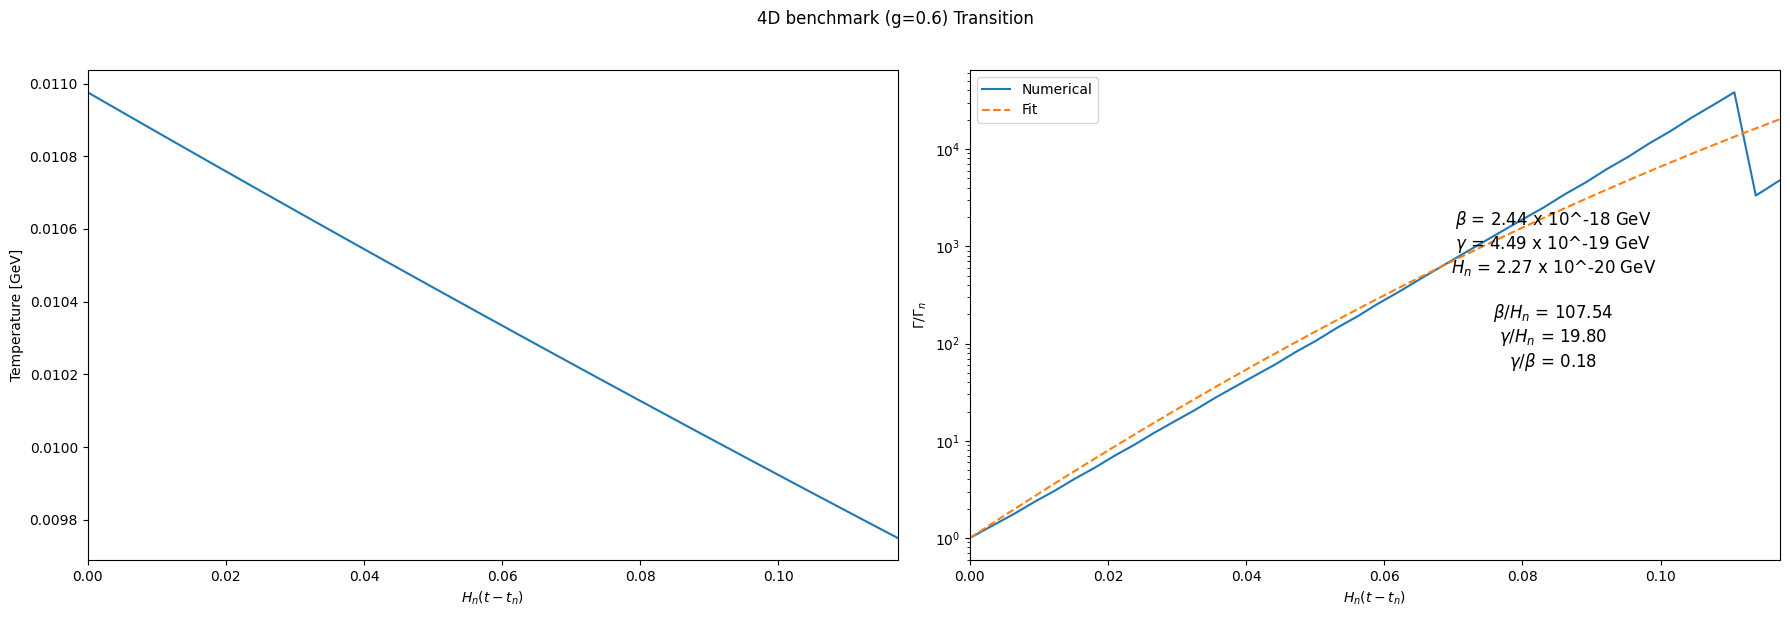

Percolation at 1.17e-01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['text.usetex'] = False

if len(times) == 0 or len(Gamma_t) == 0 or len(Temps_t) == 0 or len(H_t) == 0:
    raise RuntimeError("beta(...) returned empty arrays, so the nucleation-fit plot cannot be made.")

Gamma_n = float(Gamma_t[0])
H_n = float(H_t[0])

def scientific_notation(number):
    """Return a string in scientific notation for display."""
    number = float(number)
    if not np.isfinite(number) or number == 0.0:
        return "0"
    exponent = int(np.floor(np.log10(abs(number))))
    coefficient = number / (10 ** exponent)
    return f"{coefficient:.2f} x 10^{exponent}"

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# -------- temperature evolution --------
axes[0].plot(times, Temps_t)
axes[0].set_xlabel(r"$H_n (t - t_n)$")
axes[0].set_ylabel(f"Temperature [{units}]")
axes[0].set_xlim(times[0], times[-1])

# -------- parameter box text --------
beta_dim = beta_Hn * H_n if np.isfinite(beta_Hn) and np.isfinite(H_n) else np.nan
gamma_dim = gamma_Hn * H_n if np.isfinite(gamma_Hn) and np.isfinite(H_n) else np.nan
gamma_over_beta = gamma_Hn / beta_Hn if np.isfinite(gamma_Hn) and np.isfinite(beta_Hn) and beta_Hn != 0 else np.nan

box_text = (
    f"$\\beta$ = {scientific_notation(beta_dim)} {units}\n"
    f"$\\gamma$ = {scientific_notation(gamma_dim)} {units}\n"
    f"$H_n$ = {scientific_notation(H_n)} {units}\n\n"
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = {gamma_over_beta:.2f}" if np.isfinite(gamma_over_beta)
    else
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = nan"
)

# -------- Gamma/Gamma_n and fit --------
mask_gamma_plot = np.isfinite(Gamma_t) & (Gamma_t > 0)
if np.any(mask_gamma_plot):
    axes[1].plot(times[mask_gamma_plot], Gamma_t[mask_gamma_plot] / Gamma_n, label="Numerical")

tfit = np.linspace(times[0], times[-1], 200, endpoint=True)
fit_curve = np.exp(beta_Hn * tfit - (gamma_Hn * tfit) ** 2 / 2.0)
fit_curve[~np.isfinite(fit_curve)] = np.nan
fit_curve[fit_curve <= 0] = np.nan
axes[1].plot(tfit, fit_curve, label="Fit", linestyle='--')

axes[1].set_xlabel(r"$H_n (t - t_n)$")
axes[1].set_ylabel(r"$\Gamma / \Gamma_n$")
axes[1].set_yscale('log')
axes[1].set_xlim(times[0], times[-1])

# Put text box inside right panel
axes[1].text(
    0.72, 0.55,
    box_text,
    fontsize='large',
    transform=axes[1].transAxes,
    horizontalalignment='center',
    verticalalignment='center'
)

axes[1].legend()

plt.suptitle(f'{description} Transition', y=1.02)
plt.tight_layout()

if 'figure_dir' in globals():
    os.makedirs(figure_dir, exist_ok=True)
    plt.savefig(os.path.join(figure_dir, f"nucleation_{description}.pdf"), dpi=300, bbox_inches='tight')

plt.show()

print(f"Percolation at {times[-1]:.2e}")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving NG15.pkl to NG15.pkl


In [ ]:
import matplotlib.pyplot as plt

plt.ion()          # re-enable interactive plotting
plt.close("all")   # clean broken figures


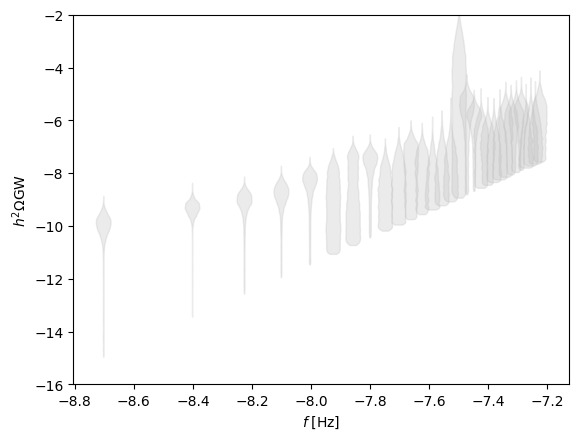

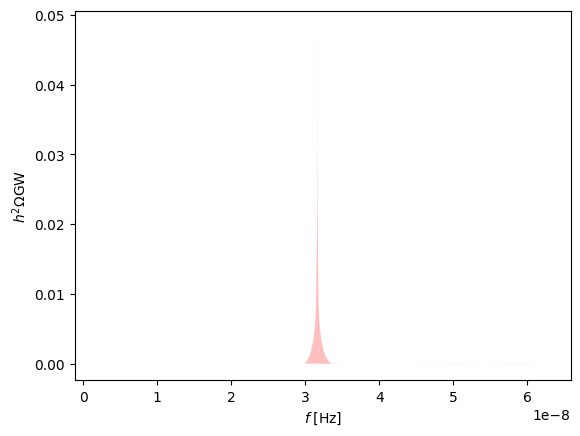

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pkl_path = "NG15.pkl"

with open(pkl_path, "rb") as f:
    fig, ax = pickle.load(f)

fig_linear, ax_linear = plt.subplots(figsize=fig.get_size_inches())

for collection in ax.collections:
    if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
        path = collection.get_paths()[0]
        vertices = path.vertices

        if len(vertices) > 0:
            x_log = vertices[:, 0]
            y_log = vertices[:, 1]

            x_linear = 10**x_log
            y_linear = 10**y_log

            ax_linear.fill(
                x_linear,
                y_linear,
                facecolor="red",        # <-- force red
                edgecolor="none",       # cleaner for papers
                alpha=0.25,             # good transparency
            )

ax_linear.set_xscale("linear")
ax_linear.set_yscale("linear")
ax_linear.set_xlabel(ax.get_xlabel())
ax_linear.set_ylabel(ax.get_ylabel())
ax_linear.set_title(ax.get_title())

plt.show()


In [ ]:
x=(alpha+1)**(1/4)

In [ ]:
T_reh=x*T_perc

Is physical? False
T_crit = 0.37550000000000777 GeV
T_nuc = 0.0109758637022271 GeV
T_perc = 0.009750283278917355 GeV
T_completion = 0.009416132345512163 GeV
T_min = 0.002002578404185474 GeV
Minimal value of P_f = 0.0
alpha = 0.4171029722393213, alpha_inf = 1513.7198497951376, alpha_eq = 94.37288118570712
gamma_* = 7667440308554820.0, gamma_eq = -16.035356002801468
Is runaway? False
R* H* = 0.053026672902914934


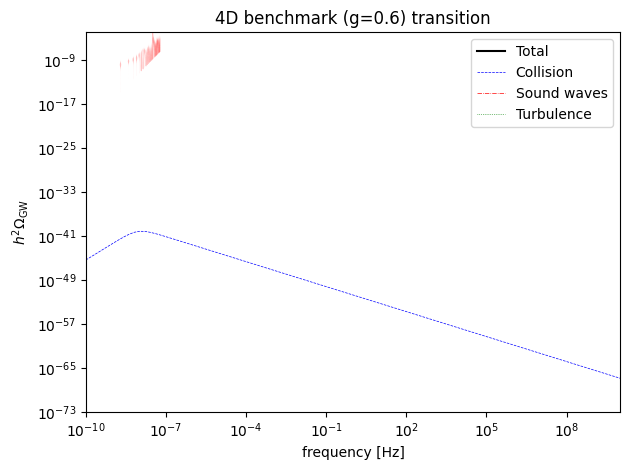

In [ ]:
import pickle
import contextlib
import os
import numpy as np
from GWparams import GW_SuperCooled

def print_params():
    print(f"Is physical? {is_physical}")

    # Only print these if they exist in the current notebook
    if 'lambdaf' in globals():
        print(f"lambda = {lambdaf}")
    if 'gX' in globals():
        print(f"g = {gX}")
    if 'vev' in globals():
        print(f"vev = {vev} {units}")
    if 'lambdaf' in globals() and 'vev' in globals():
        print(f"m_phi = {np.sqrt(2 * lambdaf) * vev} {units}")
    if 'gX' in globals() and 'vev' in globals():
        print(f"m_Z = {gX * vev} {units}")

    print(f"T_crit = {T_max} {units}")
    print(f"T_nuc = {T_nuc} {units}")
    print(f"T_perc = {T_perc} {units}")
    print(f"T_completion = {T_completion} {units}")
    print(f"T_min = {T_min} {units}")

    if 'T_reh' in globals():
        print(f"T_reh = {T_reh} {units}")

    if 'logP_f' in globals():
        print(f"Minimal value of P_f = {np.nanmin(np.exp(logP_f))}")

    print(f"alpha = {alpha}, alpha_inf = {alpha_inf}, alpha_eq = {alpha_eq}")
    print(f"gamma_* = {gamma_star}, gamma_eq = {gamma_eq}")

    if np.isfinite(alpha) and np.isfinite(alpha_inf):
        print(f"Is runaway? {alpha > alpha_inf}")
    else:
        print("Is runaway? nan")

    if np.isfinite(R_star) and np.isfinite(H_star):
        print(f"R* H* = {R_star * H_star}")
    else:
        print("R* H* = nan")

# Ensure figure directory exists
os.makedirs(figure_dir, exist_ok=True)

# Save summary text
with open(os.path.join(figure_dir, f"{description}.txt"), "w") as f:
    with contextlib.redirect_stdout(f):
        print_params()

log_freq_min = -10
log_freq_max = 10

inst = None

if np.isfinite(T_perc) and np.isfinite(alpha) and np.isfinite(alpha_inf) and np.isfinite(alpha_eq) \
   and np.isfinite(R_star) and np.isfinite(gamma_star) and np.isfinite(H_star) and np.isfinite(c_s2):

    inst = GW_SuperCooled(
        T_perc,
        alpha,
        alpha_inf,
        alpha_eq,
        R_star,
        gamma_star,
        H_star,
        c_s=np.sqrt(c_s2),
        units=units
    )

    print_params()

    x = np.logspace(log_freq_min, log_freq_max, 100)

    # Create figure here if not already created
    if 'fig_linear' not in globals() or 'ax_linear' not in globals():
        import matplotlib.pyplot as plt
        fig_linear, ax_linear = plt.subplots(figsize=(7, 5))

    ax_linear.plot(x, inst.Omegah2(x), label="Total", color='black')
    ax_linear.plot(x, inst.Omegah2coll(x), label="Collision", linewidth=0.5, color='blue', linestyle='--')
    ax_linear.plot(x, inst.Omegah2sw(x), label="Sound waves", linewidth=0.5, color='red', linestyle='-.')
    ax_linear.plot(x, inst.Omegah2turb(x), label="Turbulence", linewidth=0.5, color='green', linestyle=':')

    ax_linear.set_xlim(x[0], x[-1])
    ax_linear.set_ylim(1e-73, 1e-4)
    ax_linear.set_xscale('log')
    ax_linear.set_yscale('log')
    ax_linear.set_xlabel('frequency [Hz]')
    ax_linear.set_ylabel(r'$h^2 \Omega_{\rm GW}$')
    ax_linear.legend()
    ax_linear.set_title(f'{description} transition', y=1)

    fig_linear.tight_layout()
    fig_linear.savefig(os.path.join(figure_dir, f"GW_{description}.pdf"), dpi=300, bbox_inches='tight')
else:
    print("GW spectrum not generated: one or more required inputs are not finite.")

# Save spectrum object for future plotting
if is_physical and inst is not None:
    with open(os.path.join(figure_dir, f"GW_{description}.pkl"), "wb") as f:
        pickle.dump(inst, f)

fig_linear


Using RUNAWAY GW inputs:
T* (T_nuc)    = 1.097586e-02 GeV
alpha         = 4.508477e+04
beta/H        = 5.443384e+01
wall velocity = 1.0
g*            = 10.75

f_peak = 6.797664e-08 Hz
h^2 Omega_peak = 1.185233e-08
Loaded NANOGrav band.


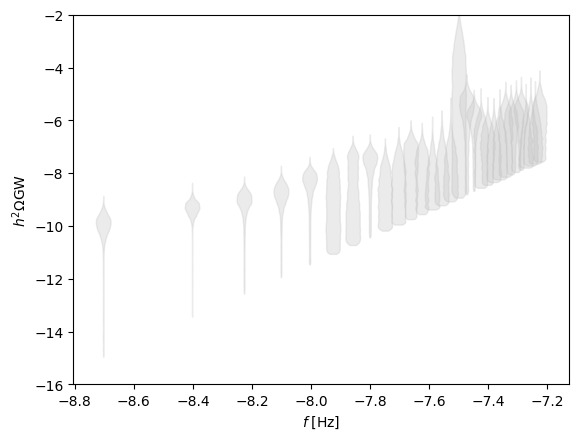

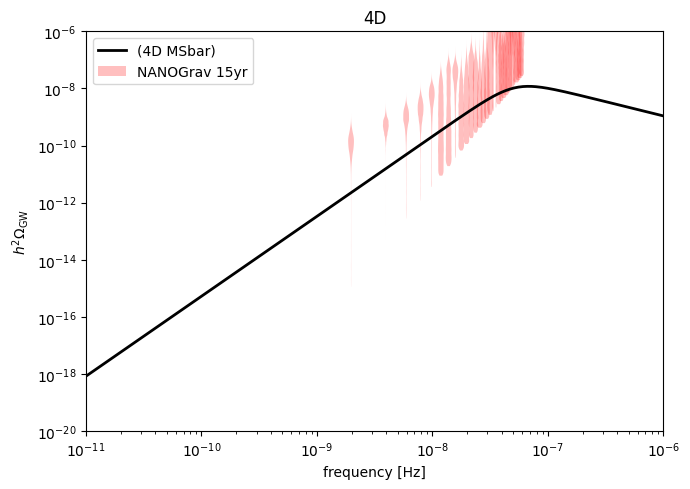


Saved:
./figures/GW_runaway_env_4D.pdf
./figures/GW_runaway_env_4D.pkl


In [54]:
# ============================================================
# RUNAWAY-CORRECT Gravitational Wave Spectrum (Envelope Approx)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

description = "4D"
units = "GeV"
figure_dir = "./figures/"
os.makedirs(figure_dir, exist_ok=True)

# ===============================
# Inputs from your PT computation
# ===============================
T_star = float(T_nuc)
alpha_star = float(alpha_val)
beta_over_H = float(beta_H)
vw = 1.0                      # runaway → vw → 1
gstar = 10.75                 # or 100 depending on model

print("\nUsing RUNAWAY GW inputs:")
print(f"T* (T_nuc)    = {T_star:.6e} GeV")
print(f"alpha         = {alpha_val:.6e}")
print(f"beta/H        = {beta_H:.6e}")
print(f"wall velocity = {vw}")
print(f"g*            = {gstar}")

# =============================================
# 1. Envelope Approximation (Huber & Konstandin)
# =============================================

def kappa_phi_runaway(alpha):
    """
    For runaway walls, almost all vacuum energy goes to scalar field gradient energy:
    κ_φ ≈ 1.
    """
    return alpha / (1.0 + alpha)

def f_peak_env(Tstar, beta_over_H, gstar=10.75):
    """
    Peak frequency today for the envelope approximation.
    Huber & Konstandin (2008), Caprini et al. (2016).
    """
    Tstar = float(Tstar)
    pref = 1.65e-5  # Hz
    return pref * (beta_over_H) * (Tstar / 100.0) * (gstar / 100.0) ** (1.0 / 6.0)

def omega_peak_env(alpha, beta_over_H, gstar=10.75):
    """
    Peak amplitude of scalar-field collision GWs.
    """
    kappa_phi = alpha / (1.0 + alpha)
    return (
        1.67e-5
        * (100.0 / gstar) ** (1.0 / 3.0)
        * (1.0 / beta_over_H) ** 2
        * (kappa_phi * alpha / (1.0 + alpha)) ** 2
    )

def S_env(x):
    """
    Spectral shape for envelope GW spectrum.
    """
    return (3.8 * x**2.8) / (1.0 + 2.8 * x**3.8)

def omega_gw_env(f_hz, Tstar, alpha, beta_over_H, gstar=10.75):
    fp = f_peak_env(Tstar, beta_over_H, gstar=gstar)
    op = omega_peak_env(alpha, beta_over_H, gstar=gstar)
    return op * S_env(f_hz / fp)

# ================================
# Build spectrum
# ================================
freq = np.logspace(-11, -6, 400)
omega = omega_gw_env(freq, T_star, alpha_star, beta_over_H, gstar=gstar)

f_peak = f_peak_env(T_star, beta_over_H, gstar=gstar)
omega_peak = omega_peak_env(alpha_star, beta_over_H, gstar=gstar)

print(f"\nf_peak = {f_peak:.6e} Hz")
print(f"h^2 Omega_peak = {omega_peak:.6e}")

# ===============================
# Load NANOGrav (if available)
# ===============================
nanograv_file = "NG15.pkl"
ng_loaded = False
if os.path.exists(nanograv_file):
    with open(nanograv_file, "rb") as f:
        ng_data = pickle.load(f)
    ng_loaded = True
    print("Loaded NANOGrav band.")
else:
    print("NANOGrav file not found.")

# Same overlay function you already wrote
# (Keeping your existing implementation)
# ----------------------------------------

# ===============================
# Plot
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(freq, omega, color="black", lw=2, label="(4D MSbar)")

if ng_loaded:
    plot_nanograv_overlay(ax, ng_data)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(freq[0], freq[-1])
ax.set_ylim(1e-20, 1e-6)
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel(r"$h^2 \Omega_{\rm GW}$")
ax.set_title(description)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"GW_runaway_env_{description}.pdf"), dpi=300)
plt.show()

# ===============================
# Save Result
# ===============================
gw_result = {
    "description": description,
    "scheme": "runaway_envelope",
    "T_star_GeV": T_star,
    "alpha": alpha_val,
    "beta_over_H": beta_H,
    "vw": vw,
    "gstar": gstar,
    "frequency_Hz": freq,
    "h2OmegaGW": omega,
    "f_peak_Hz": f_peak,
    "omega_peak": omega_peak,
}

with open(os.path.join(figure_dir, f"GW_runaway_env_{description}.pkl"), "wb") as f:
    pickle.dump(gw_result, f)

print("\nSaved:")
print(os.path.join(figure_dir, f"GW_runaway_env_{description}.pdf"))
print(os.path.join(figure_dir, f"GW_runaway_env_{description}.pkl"))

Loaded NANOGrav file: NG15.pkl


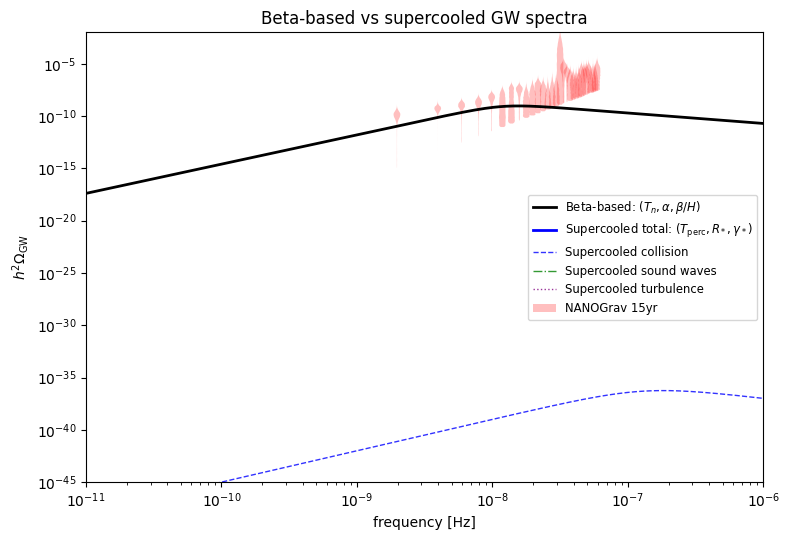


--- Beta-based inputs ---
T* = Tn = 1.097586e-02 GeV
alpha = 4.508477e+04
beta/H = 5.443384e+01
vw = 1.0
g* = 10.75
f_peak(beta-based) = 1.560945e-08 Hz
Omega_peak(beta-based) = 9.181385e-10

--- Supercooled inputs ---
T_perc = 9.750283e-03 GeV
alpha = 4.171030e-01
alpha_inf = 1.513720e+03
alpha_eq = 9.437288e+01
R_star = 2.283123e+18
gamma_star = 7.667440e+15
H_star = 2.322550e-20
c_s^2 = -8.121825e-01


In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from GWparams import GW_SuperCooled

# ============================================================
# Settings
# ============================================================

units = "GeV"
figure_dir = "./figures/"
os.makedirs(figure_dir, exist_ok=True)

comparison_description = f"{description}_beta_vs_supercooled"
nanograv_file = "NG15.pkl"

# ============================================================
# 1) Paper-style beta-based GW spectrum
# ============================================================

def kappa_collision_relativistic(alpha):
    alpha = float(alpha)
    if not np.isfinite(alpha) or alpha <= 0.0:
        return 0.0
    return alpha / (1.0 + alpha)

def f_peak_today_collision(Tstar_GeV, beta_over_H, vw=1.0, gstar=10.75):
    Tstar_GeV = float(Tstar_GeV)
    beta_over_H = float(beta_over_H)
    vw = float(vw)
    gstar = float(gstar)

    pref = 1.65e-5  # Hz
    shape_vw = 0.62 / (1.8 - 0.1 * vw + vw**2)
    return pref * shape_vw * beta_over_H * (Tstar_GeV / 100.0) * (gstar / 100.0) ** (1.0 / 6.0)

def omega_peak_collision(alpha, beta_over_H, vw=1.0, gstar=10.75):
    alpha = float(alpha)
    beta_over_H = float(beta_over_H)
    vw = float(vw)
    gstar = float(gstar)

    if not np.isfinite(alpha) or not np.isfinite(beta_over_H):
        return np.nan
    if alpha <= 0.0 or beta_over_H <= 0.0:
        return 0.0

    kappa = kappa_collision_relativistic(alpha)
    pref = 1.67e-5
    vw_factor = 0.11 * vw**3 / (0.42 + vw**2)

    return (
        pref
        * (100.0 / gstar) ** (1.0 / 3.0)
        * (1.0 / beta_over_H) ** 2
        * (kappa * alpha / (1.0 + alpha)) ** 2
        * vw_factor
    )

def spectral_shape_collision(x):
    x = np.asarray(x, dtype=float)
    return 3.8 * x**2.8 / (1.0 + 2.8 * x**3.8)

def omega_gw_bulkflow_beta(f_hz, Tstar_GeV, alpha, beta_over_H, vw=1.0, gstar=10.75):
    f_hz = np.asarray(f_hz, dtype=float)
    fp = f_peak_today_collision(Tstar_GeV, beta_over_H, vw=vw, gstar=gstar)
    op = omega_peak_collision(alpha, beta_over_H, vw=vw, gstar=gstar)
    x = f_hz / fp
    return op * spectral_shape_collision(x)

# Paper-style inputs: T*=Tn, alpha, beta/H, vw=1
T_star_beta = float(T_nuc)
alpha_beta = float(alpha_val)
beta_over_H = float(beta_H)
vw = 1.0
gstar = 10.75

# ============================================================
# 2) Supercooled ELENA GW spectrum
# ============================================================

def build_supercooled_instance():
    required = [T_perc, alpha_val, alpha_inf, alpha_eq, R_star, gamma_star, H_star, c_s2]
    if not all(np.isfinite(v) for v in required):
        return None

    return GW_SuperCooled(
        float(T_perc),
        float(alpha_val),
        float(alpha_inf),
        float(alpha_eq),
        float(R_star),
        float(gamma_star),
        float(H_star),
        c_s=np.sqrt(float(c_s2)),
        v_w=1.0,
        units=units
    )

inst_supercooled = build_supercooled_instance()

# ============================================================
# 3) NANOGrav overlay helpers
# ============================================================

def overlay_nanograv_from_figure(ax, ng_data):
    """
    Copy artists from a stored matplotlib Figure onto ax,
    then close the source figure so it does not display separately.
    Returns True if successfully copied, False otherwise.
    """
    src_fig = None

    if isinstance(ng_data, Figure):
        src_fig = ng_data
    elif isinstance(ng_data, (tuple, list)):
        for item in ng_data:
            if isinstance(item, Figure):
                src_fig = item
                break

    if src_fig is None or len(src_fig.axes) == 0:
        return False

    src_ax = src_fig.axes[0]
    has_labeled_nanograv = False

    # Extract and plot data from collections (e.g., fill_between regions)
    for collection in src_ax.collections:
        if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
            path = collection.get_paths()[0]
            vertices = path.vertices

            x_log = vertices[:, 0]
            y_log = vertices[:, 1]

            # Apply 10** transformation, assuming data in pkl is log-scaled
            x_linear = 10**x_log
            y_linear = 10**y_log

            label_text = "NANOGrav 15yr" if not has_labeled_nanograv else None
            ax.fill(
                x_linear,
                y_linear,
                facecolor="red",
                edgecolor="none",
                alpha=0.25,
                label=label_text,
            )
            if not has_labeled_nanograv:
                has_labeled_nanograv = True

    # Extract and plot data from lines
    for line in src_ax.lines:
        x_log = line.get_xdata()
        y_log = line.get_ydata()

        # Apply 10** transformation (assuming consistency with collections)
        x_linear = 10**x_log
        y_linear = 10**y_log

        label_text = line.get_label()
        if not has_labeled_nanograv and (not label_text or label_text.startswith("_") or "NANOGrav" in label_text):
            label_text = "NANOGrav 15yr"
            has_labeled_nanograv = True
        elif has_labeled_nanograv:
            label_text = None # Don't repeat label

        ax.plot(
            x_linear, y_linear,
            color="red",
            alpha=0.9,
            linewidth=1.5,
            linestyle=line.get_linestyle(),
            label=label_text
        )

    plt.close(src_fig)
    return True

# ============================================================
# 4) Load NANOGrav first and suppress separate figure
# ============================================================

ng_loaded = False
ng_data = None

if os.path.exists(nanograv_file):
    with open(nanograv_file, "rb") as f:
        ng_data = pickle.load(f)
    ng_loaded = True
    print(f"Loaded NANOGrav file: {nanograv_file}")

    # If loading the pickle created a figure, close it now
    if isinstance(ng_data, Figure):
        plt.close(ng_data)
    elif isinstance(ng_data, (tuple, list)):
        for item in ng_data:
            if isinstance(item, Figure):
                plt.close(item)
else:
    print(f"NANOGrav file not found: {nanograv_file}")

# ============================================================
# 5) Frequency grid and spectra
# ============================================================

freq = np.logspace(-11, -6, 500)

omega_beta = omega_gw_bulkflow_beta(
    freq,
    Tstar_GeV=T_star_beta,
    alpha=alpha_beta,
    beta_over_H=beta_over_H,
    vw=vw,
    gstar=gstar
)

if inst_supercooled is not None:
    omega_supercooled = inst_supercooled.Omegah2(freq)
    omega_coll = inst_supercooled.Omegah2coll(freq)
    omega_sw = inst_supercooled.Omegah2sw(freq)
    omega_turb = inst_supercooled.Omegah2turb(freq)
else:
    omega_supercooled = None
    omega_coll = None
    omega_sw = None
    omega_turb = None

# ============================================================
# 6) Main comparison figure
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

# beta-based curve
ax.plot(
    freq,
    omega_beta,
    color="black",
    linewidth=2,
    label=r"Beta-based: $(T_n,\alpha,\beta/H)$"
)

# supercooled curve + components
if omega_supercooled is not None:
    ax.plot(
        freq,
        omega_supercooled,
        color="blue",
        linewidth=2,
        label=r"Supercooled total: $(T_{\rm perc},R_*,\gamma_*)$"
    )
    ax.plot(freq, omega_coll, color="blue", linestyle="--", linewidth=1, alpha=0.8, label="Supercooled collision")
    ax.plot(freq, omega_sw, color="green", linestyle="-.", linewidth=1, alpha=0.8, label="Supercooled sound waves")
    ax.plot(freq, omega_turb, color="purple", linestyle=":", linewidth=1, alpha=0.8, label="Supercooled turbulence")

# NANOGrav overlay
if ng_loaded:
    # Always try to use overlay_nanograv_from_figure if ng_data is a Figure/Axes object
    if isinstance(ng_data, Figure) or (isinstance(ng_data, tuple) and any(isinstance(item, Figure) for item in ng_data)):
        ok_plot = overlay_nanograv_from_figure(ax, ng_data)
    # If it's not a Figure/Axes object, then it's some other data format (not expected from NG15.pkl, but for robustness)
    # For this notebook, we only expect the Figure/Axes tuple, so this else branch is practically unreachable for NG15.pkl
    # but kept for hypothetical other .pkl formats.
    else:
        print("NANOGrav data is not in an expected Figure/Axes format.")
        ok_plot = False

    if not ok_plot:
        print("Could not parse NANOGrav pickle format for plotting.")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(freq[0], freq[-1])
ax.set_ylim(1e-45, 1e-2)

ax.set_xlabel("frequency [Hz]")
ax.set_ylabel(r"$h^2 \Omega_{\rm GW}$")
ax.set_title("Beta-based vs supercooled GW spectra")
ax.legend(fontsize="small")

plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, f"GW_compare_beta_vs_supercooled_{comparison_description}.pdf"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# 7) Summary printout
# ============================================================

print("\n--- Beta-based inputs ---")
print(f"T* = Tn = {T_star_beta:.6e} GeV")
print(f"alpha = {alpha_beta:.6e}")
print(f"beta/H = {beta_over_H:.6e}")
print(f"vw = {vw}")
print(f"g* = {gstar}")
print(f"f_peak(beta-based) = {f_peak_today_collision(T_star_beta, beta_over_H, vw=vw, gstar=gstar):.6e} Hz")
print(f"Omega_peak(beta-based) = {omega_peak_collision(alpha_beta, beta_over_H, vw=vw, gstar=gstar):.6e}")

if inst_supercooled is not None:
    print("\n--- Supercooled inputs ---")
    print(f"T_perc = {float(T_perc):.6e} GeV")
    print(f"alpha = {float(alpha):.6e}")
    print(f"alpha_inf = {float(alpha_inf):.6e}")
    print(f"alpha_eq = {float(alpha_eq):.6e}")
    print(f"R_star = {float(R_star):.6e}")
    print(f"gamma_star = {float(gamma_star):.6e}")
    print(f"H_star = {float(H_star):.6e}")
    print(f"c_s^2 = {float(c_s2):.6e}")
else:
    print("\nSupercooled instance could not be built from the current parameters.")